<a href="https://colab.research.google.com/github/donald-ye/FT-methods-superposition/blob/main/Final_with_LoRA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[SUP-AE] step 200/4000 train_total=5.7787 (recon=0.0375, cls=5.7412) | val_total=5.6894 (recon=0.0375, cls=5.6519) | val_acc(shape/scale/orient)=0.451/0.446/0.029
[SUP-AE] step 400/4000 train_total=5.6191 (recon=0.0295, cls=5.5897) | val_total=5.6509 (recon=0.0287, cls=5.6222) | val_acc(shape/scale/orient)=0.436/0.460/0.026
[SUP-AE] step 600/4000 train_total=5.6263 (recon=0.0260, cls=5.6004) | val_total=5.6573 (recon=0.0288, cls=5.6286) | val_acc(shape/scale/orient)=0.458/0.494/0.027
[SUP-AE] step 800/4000 train_total=5.1432 (recon=0.0244, cls=5.1187) | val_total=5.2899 (recon=0.0236, cls=5.2663) | val_acc(shape/scale/orient)=0.542/0.553/0.053
[SUP-AE] step 1000/4000 train_total=4.1751 (recon=0.0220, cls=4.1530) | val_total=4.3652 (recon=0.0222, cls=4.3430) | val_acc(shape/scale/orient)=0.793/0.522/0.128
[SUP-AE] step 1200/4000 train_total=3.1357 (recon=0.0227, cls=3.1130) | val_total=3.5922 (recon=0.0212, cls=3.5711) | val_acc(shape/scale/orient)=0.947/0.629/0.205
[SUP-AE] step 1400/4

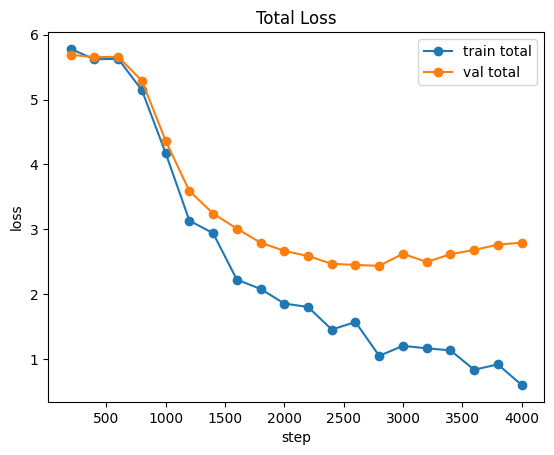

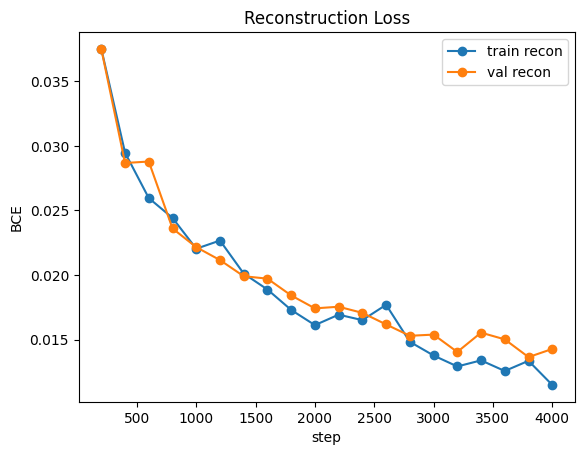

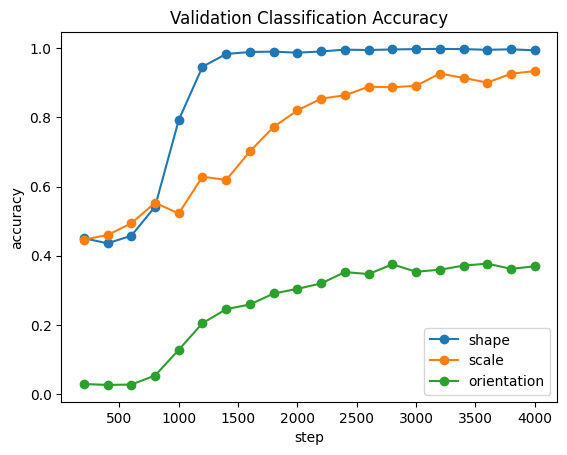

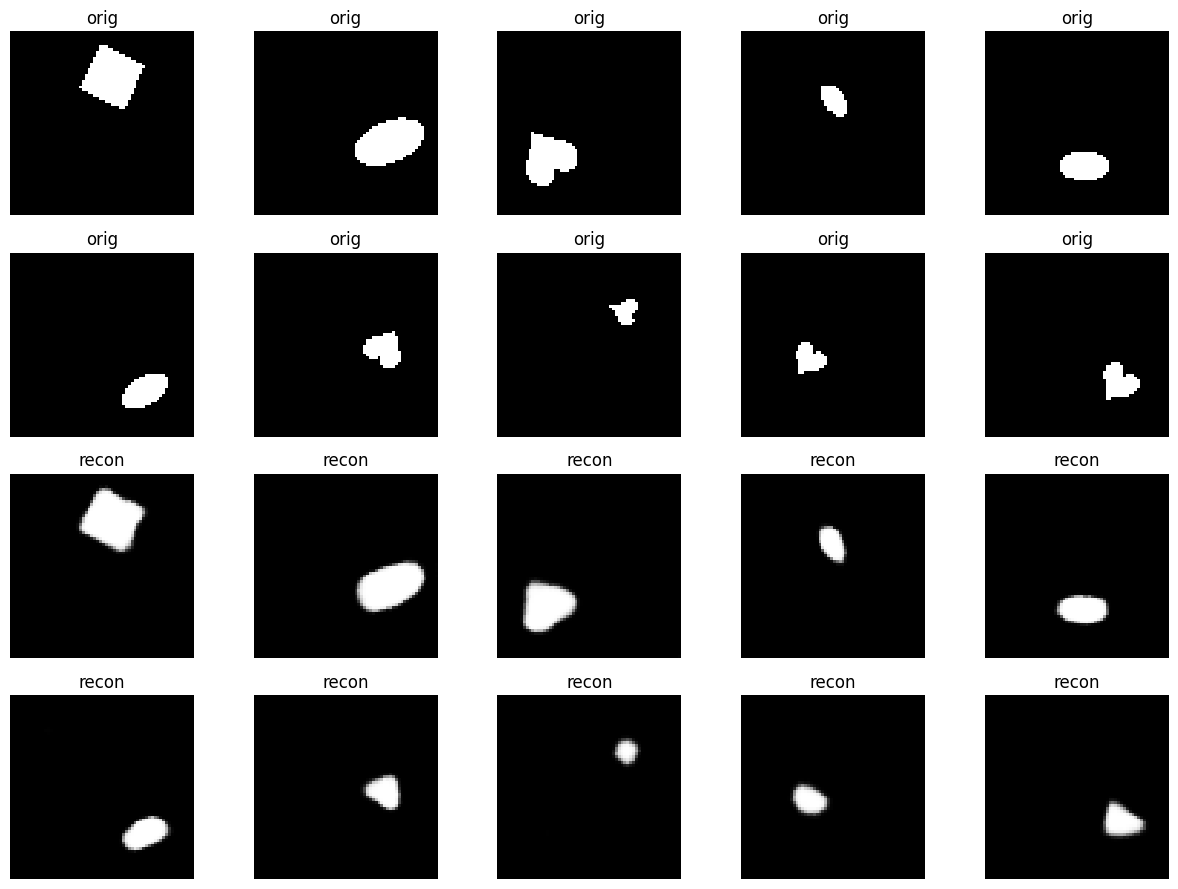

Feature shapes:
train_feats: torch.Size([11904, 128])
val_feats: torch.Size([1920, 128])
[Probe 1/20] train(shape/scale/orient)=0.264/0.194/0.036 | val(shape/scale/orient)=0.259/0.182/0.036
[Probe 2/20] train(shape/scale/orient)=0.282/0.209/0.038 | val(shape/scale/orient)=0.280/0.196/0.036
[Probe 3/20] train(shape/scale/orient)=0.305/0.224/0.040 | val(shape/scale/orient)=0.299/0.215/0.039
[Probe 4/20] train(shape/scale/orient)=0.337/0.240/0.044 | val(shape/scale/orient)=0.326/0.232/0.040
[Probe 5/20] train(shape/scale/orient)=0.369/0.254/0.048 | val(shape/scale/orient)=0.356/0.255/0.045
[Probe 6/20] train(shape/scale/orient)=0.406/0.268/0.052 | val(shape/scale/orient)=0.396/0.268/0.052
[Probe 7/20] train(shape/scale/orient)=0.442/0.279/0.059 | val(shape/scale/orient)=0.430/0.286/0.056
[Probe 8/20] train(shape/scale/orient)=0.486/0.292/0.069 | val(shape/scale/orient)=0.481/0.297/0.065
[Probe 9/20] train(shape/scale/orient)=0.530/0.305/0.082 | val(shape/scale/orient)=0.529/0.316/0.082
[P

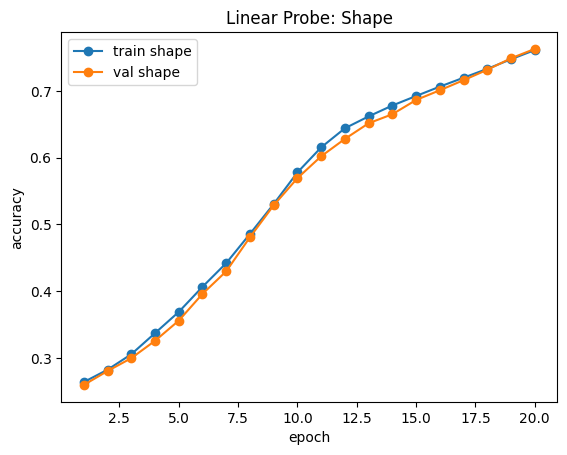

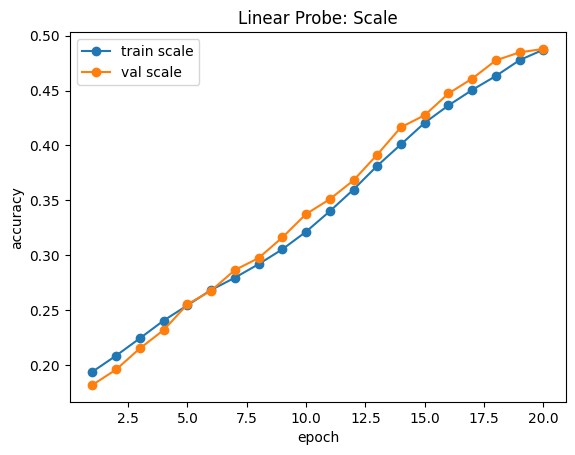

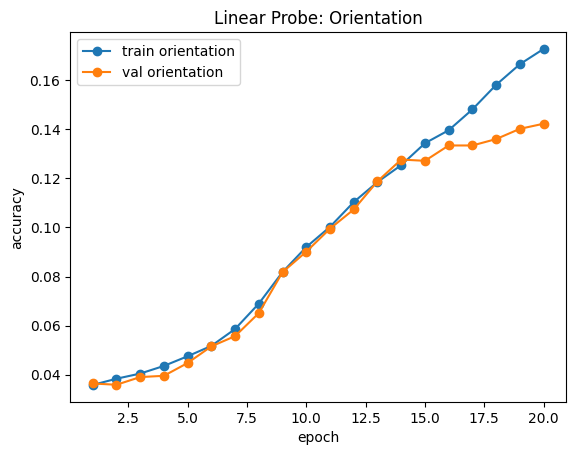


=== SUPERPOSITION ANALYSIS ===


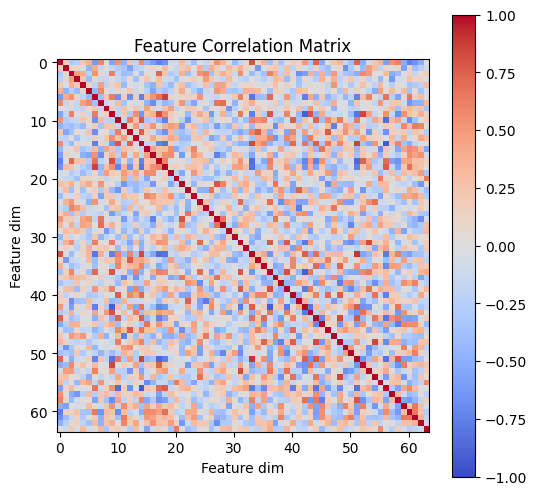

Mean |off-diagonal correlation|: 0.2807


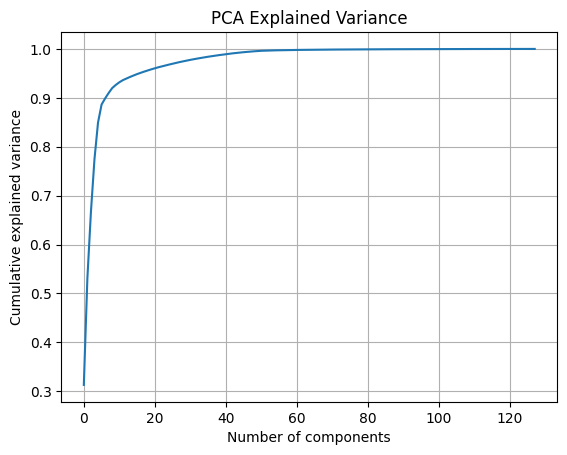

Top 10 components explain: 0.9264
Top 20 components explain: 0.9582


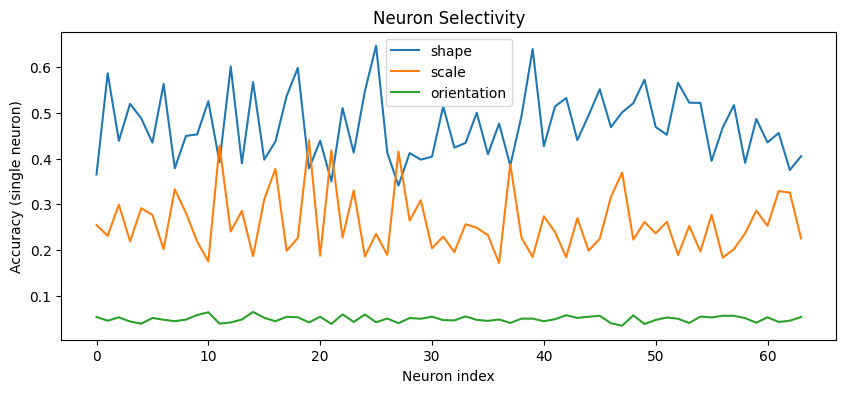


Top neurons per factor:
shape: max=0.647
scale: max=0.441
orientation: max=0.065
Superposition score: 0.2807

========== FINAL RESULTS ==========
Probe Shape       train=0.7613 val=0.7630
Probe Scale       train=0.4873 val=0.4880
Probe Orientation train=0.1726 val=0.1422


In [ ]:
# ============================================================
# UPDATED: Stronger Supervised Autoencoder + Linear Probe
# dSprites
# ============================================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, Dict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


# -----------------------------
# 0) Reproducibility
# -----------------------------
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# -----------------------------
# 1) Dataset
# -----------------------------
class DSpritesDataset(Dataset):
    """
    Returns:
      x_img: (1,64,64)
      targets:
        shape: [0..2]
        scale: [0..5]
        orientation: [0..39]
    """
    def __init__(self, npz_path: str, indices: np.ndarray):
        if not os.path.exists(npz_path):
            raise FileNotFoundError(f"Could not find {npz_path}")

        data = np.load(npz_path, allow_pickle=True)
        self.imgs = data["imgs"]
        self.latents = data["latents_classes"]
        self.indices = indices.astype(np.int64)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        img = self.imgs[idx].astype(np.float32)
        x_img = torch.from_numpy(img).unsqueeze(0)

        lat = self.latents[idx].astype(np.int64)
        targets = {
            "shape": torch.tensor(lat[1], dtype=torch.long),
            "scale": torch.tensor(lat[2], dtype=torch.long),
            "orientation": torch.tensor(lat[3], dtype=torch.long),
        }
        return x_img, targets


def make_train_val_indices(n_total: int, n_train: int, n_val: int, seed: int) -> Tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    perm = rng.permutation(n_total)
    train_idx = perm[:n_train]
    val_idx = perm[n_train:n_train + n_val]
    return train_idx, val_idx


# -----------------------------
# 2) Stronger Model
# -----------------------------
class CNNEncoder(nn.Module):
    def __init__(self, rep_dim=128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=4, stride=2, padding=1),    # 64 -> 32
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1),   # 32 -> 16
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),   # 16 -> 8
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 8 -> 4
            nn.ReLU(),
        )
        self.fc = nn.Linear(128 * 4 * 4, rep_dim)

    def forward(self, x):
        z = self.conv(x)
        z = z.view(z.size(0), -1)
        h = self.fc(z)
        return h


class CNNDecoder(nn.Module):
    def __init__(self, rep_dim=128):
        super().__init__()
        self.fc = nn.Linear(rep_dim, 128 * 4 * 4)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 4 -> 8
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # 8 -> 16
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),   # 16 -> 32
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=1),    # 32 -> 64
            nn.Sigmoid(),
        )

    def forward(self, h):
        z = self.fc(h)
        z = z.view(h.size(0), 128, 4, 4)
        x_hat = self.deconv(z)
        return x_hat


class MultiHeadClassifier(nn.Module):
    def __init__(self, rep_dim=128):
        super().__init__()
        self.shape_head = nn.Linear(rep_dim, 3)
        self.scale_head = nn.Linear(rep_dim, 6)
        self.orientation_head = nn.Linear(rep_dim, 40)

    def forward(self, h):
        return {
            "shape": self.shape_head(h),
            "scale": self.scale_head(h),
            "orientation": self.orientation_head(h),
        }


class SupervisedAutoencoder(nn.Module):
    def __init__(self, rep_dim=128):
        super().__init__()
        self.encoder = CNNEncoder(rep_dim=rep_dim)
        self.decoder = CNNDecoder(rep_dim=rep_dim)
        self.clf = MultiHeadClassifier(rep_dim=rep_dim)

    def forward(self, x):
        h = self.encoder(x)
        x_hat = self.decoder(h)
        logits = self.clf(h)
        return h, x_hat, logits


# -----------------------------
# 3) Helpers
# -----------------------------
def accuracy(logits: torch.Tensor, y: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()


@torch.no_grad()
def evaluate_supervised_ae(model, loader, device, cls_weight=1.0):
    model.eval()
    ce = nn.CrossEntropyLoss()
    bce = nn.BCELoss()

    total_loss = 0.0
    total_recon = 0.0
    total_cls = 0.0
    total_n = 0

    correct = {"shape": 0, "scale": 0, "orientation": 0}

    for x, t in loader:
        x = x.to(device)
        t = {k: v.to(device) for k, v in t.items()}

        _, x_hat, logits = model(x)

        recon_loss = bce(x_hat, x)
        cls_loss = (
            ce(logits["shape"], t["shape"])
            + ce(logits["scale"], t["scale"])
            + ce(logits["orientation"], t["orientation"])
        )
        loss = recon_loss + cls_weight * cls_loss

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_recon += recon_loss.item() * bs
        total_cls += cls_loss.item() * bs
        total_n += bs

        for k in correct:
            preds = logits[k].argmax(dim=1)
            correct[k] += (preds == t[k]).sum().item()

    return {
        "loss": total_loss / total_n,
        "recon_loss": total_recon / total_n,
        "cls_loss": total_cls / total_n,
        "acc_shape": correct["shape"] / total_n,
        "acc_scale": correct["scale"] / total_n,
        "acc_orientation": correct["orientation"] / total_n,
    }


# -----------------------------
# 4) Training
# -----------------------------
def train_supervised_autoencoder(
    model,
    train_loader,
    val_loader,
    device,
    steps=4000,
    lr=1e-3,
    cls_weight=1.0,
    print_every=200,
):
    model = model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)

    ce = nn.CrossEntropyLoss()
    bce = nn.BCELoss()

    logs = {
        "step": [],
        "train_total": [],
        "train_recon": [],
        "train_cls": [],
        "val_total": [],
        "val_recon": [],
        "val_cls": [],
        "val_acc_shape": [],
        "val_acc_scale": [],
        "val_acc_orientation": [],
    }

    model.train()
    it = iter(train_loader)

    for step in range(1, steps + 1):
        try:
            x, t = next(it)
        except StopIteration:
            it = iter(train_loader)
            x, t = next(it)

        x = x.to(device)
        t = {k: v.to(device) for k, v in t.items()}

        _, x_hat, logits = model(x)

        recon_loss = bce(x_hat, x)
        cls_loss = (
            ce(logits["shape"], t["shape"])
            + ce(logits["scale"], t["scale"])
            + ce(logits["orientation"], t["orientation"])
        )
        loss = recon_loss + cls_weight * cls_loss

        opt.zero_grad()
        loss.backward()
        opt.step()

        if step % print_every == 0 or step == steps:
            val_metrics = evaluate_supervised_ae(model, val_loader, device, cls_weight=cls_weight)

            logs["step"].append(step)
            logs["train_total"].append(loss.item())
            logs["train_recon"].append(recon_loss.item())
            logs["train_cls"].append(cls_loss.item())
            logs["val_total"].append(val_metrics["loss"])
            logs["val_recon"].append(val_metrics["recon_loss"])
            logs["val_cls"].append(val_metrics["cls_loss"])
            logs["val_acc_shape"].append(val_metrics["acc_shape"])
            logs["val_acc_scale"].append(val_metrics["acc_scale"])
            logs["val_acc_orientation"].append(val_metrics["acc_orientation"])

            print(
                f"[SUP-AE] step {step}/{steps} "
                f"train_total={loss.item():.4f} "
                f"(recon={recon_loss.item():.4f}, cls={cls_loss.item():.4f}) | "
                f"val_total={val_metrics['loss']:.4f} "
                f"(recon={val_metrics['recon_loss']:.4f}, cls={val_metrics['cls_loss']:.4f}) | "
                f"val_acc(shape/scale/orient)="
                f"{val_metrics['acc_shape']:.3f}/"
                f"{val_metrics['acc_scale']:.3f}/"
                f"{val_metrics['acc_orientation']:.3f}",
                flush=True
            )

    return logs


# -----------------------------
# 5) Visualization
# -----------------------------
@torch.no_grad()
def show_reconstructions(model, loader, device, n_show=10):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n_show].to(device)

    _, x_hat, _ = model(x)

    x_np = x.cpu().numpy()
    xh_np = x_hat.cpu().numpy()

    cols = min(5, n_show)
    rows = int(np.ceil(n_show / cols))

    plt.figure(figsize=(2.5 * cols, 4.5 * rows))
    for i in range(n_show):
        ax1 = plt.subplot(rows * 2, cols, i + 1)
        ax1.imshow(x_np[i, 0], cmap="gray", interpolation="nearest")
        ax1.set_title("orig")
        ax1.axis("off")

        ax2 = plt.subplot(rows * 2, cols, rows * cols + i + 1)
        ax2.imshow(xh_np[i, 0], cmap="gray", interpolation="nearest")
        ax2.set_title("recon")
        ax2.axis("off")

    plt.tight_layout()
    plt.show()


def plot_training_curves(logs):
    steps = logs["step"]

    plt.figure()
    plt.plot(steps, logs["train_total"], marker="o", label="train total")
    plt.plot(steps, logs["val_total"], marker="o", label="val total")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title("Total Loss")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(steps, logs["train_recon"], marker="o", label="train recon")
    plt.plot(steps, logs["val_recon"], marker="o", label="val recon")
    plt.xlabel("step")
    plt.ylabel("BCE")
    plt.title("Reconstruction Loss")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(steps, logs["val_acc_shape"], marker="o", label="shape")
    plt.plot(steps, logs["val_acc_scale"], marker="o", label="scale")
    plt.plot(steps, logs["val_acc_orientation"], marker="o", label="orientation")
    plt.xlabel("step")
    plt.ylabel("accuracy")
    plt.title("Validation Classification Accuracy")
    plt.legend()
    plt.show()


# -----------------------------
# 6) Extract features
# -----------------------------
@torch.no_grad()
def extract_features(encoder, loader, device, max_samples=None):
    encoder.eval()

    all_feats = []
    all_targets = {"shape": [], "scale": [], "orientation": []}
    count = 0

    for x, targets in loader:
        x = x.to(device)
        h = encoder(x)

        bs = h.size(0)

        if max_samples is not None and count + bs > max_samples:
            keep = max_samples - count
            if keep <= 0:
                break
            h = h[:keep]
            all_feats.append(h.cpu())
            for k in all_targets:
                all_targets[k].append(targets[k][:keep])
            break

        all_feats.append(h.cpu())
        for k in all_targets:
            all_targets[k].append(targets[k])

        count += bs
        if max_samples is not None and count >= max_samples:
            break

    feats = torch.cat(all_feats, dim=0)
    targets = {k: torch.cat(v, dim=0) for k, v in all_targets.items()}
    return feats, targets


# -----------------------------
# 7) Linear Probe
# -----------------------------
class LinearProbe(nn.Module):
    def __init__(self, feat_dim):
        super().__init__()
        self.shape_head = nn.Linear(feat_dim, 3)
        self.scale_head = nn.Linear(feat_dim, 6)
        self.orientation_head = nn.Linear(feat_dim, 40)

    def forward(self, h):
        return {
            "shape": self.shape_head(h),
            "scale": self.scale_head(h),
            "orientation": self.orientation_head(h),
        }


def train_linear_probe(
    train_feats,
    train_targets,
    val_feats,
    val_targets,
    device,
    epochs=20,
    lr=1e-3,
):
    probe = LinearProbe(train_feats.shape[1]).to(device)
    opt = optim.Adam(probe.parameters(), lr=lr)
    ce = nn.CrossEntropyLoss()

    train_feats = train_feats.to(device)
    val_feats = val_feats.to(device)
    train_targets = {k: v.to(device) for k, v in train_targets.items()}
    val_targets = {k: v.to(device) for k, v in val_targets.items()}

    logs = {
        "epoch": [],
        "train_acc_shape": [],
        "train_acc_scale": [],
        "train_acc_orientation": [],
        "val_acc_shape": [],
        "val_acc_scale": [],
        "val_acc_orientation": [],
    }

    for epoch in range(1, epochs + 1):
        probe.train()

        logits = probe(train_feats)
        loss = (
            nn.CrossEntropyLoss()(logits["shape"], train_targets["shape"])
            + nn.CrossEntropyLoss()(logits["scale"], train_targets["scale"])
            + nn.CrossEntropyLoss()(logits["orientation"], train_targets["orientation"])
        )

        opt.zero_grad()
        loss.backward()
        opt.step()

        probe.eval()
        with torch.no_grad():
            train_logits = probe(train_feats)
            val_logits = probe(val_feats)

            train_acc_shape = accuracy(train_logits["shape"], train_targets["shape"])
            train_acc_scale = accuracy(train_logits["scale"], train_targets["scale"])
            train_acc_orient = accuracy(train_logits["orientation"], train_targets["orientation"])

            val_acc_shape = accuracy(val_logits["shape"], val_targets["shape"])
            val_acc_scale = accuracy(val_logits["scale"], val_targets["scale"])
            val_acc_orient = accuracy(val_logits["orientation"], val_targets["orientation"])

        logs["epoch"].append(epoch)
        logs["train_acc_shape"].append(train_acc_shape)
        logs["train_acc_scale"].append(train_acc_scale)
        logs["train_acc_orientation"].append(train_acc_orient)
        logs["val_acc_shape"].append(val_acc_shape)
        logs["val_acc_scale"].append(val_acc_scale)
        logs["val_acc_orientation"].append(val_acc_orient)

        print(
            f"[Probe {epoch}/{epochs}] "
            f"train(shape/scale/orient)="
            f"{train_acc_shape:.3f}/{train_acc_scale:.3f}/{train_acc_orient:.3f} | "
            f"val(shape/scale/orient)="
            f"{val_acc_shape:.3f}/{val_acc_scale:.3f}/{val_acc_orient:.3f}",
            flush=True
        )

    return probe, logs


def plot_probe_curves(logs):
    epochs = logs["epoch"]

    plt.figure()
    plt.plot(epochs, logs["train_acc_shape"], marker="o", label="train shape")
    plt.plot(epochs, logs["val_acc_shape"], marker="o", label="val shape")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title("Linear Probe: Shape")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, logs["train_acc_scale"], marker="o", label="train scale")
    plt.plot(epochs, logs["val_acc_scale"], marker="o", label="val scale")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title("Linear Probe: Scale")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, logs["train_acc_orientation"], marker="o", label="train orientation")
    plt.plot(epochs, logs["val_acc_orientation"], marker="o", label="val orientation")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title("Linear Probe: Orientation")
    plt.legend()
    plt.show()

def plot_feature_correlation(feats, max_dims=64):
    feats = feats - feats.mean(dim=0, keepdim=True)

    if feats.shape[1] > max_dims:
        feats = feats[:, :max_dims]

    corr = torch.corrcoef(feats.T).cpu().numpy()

    plt.figure(figsize=(6, 6))
    plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar()
    plt.title("Feature Correlation Matrix")
    plt.xlabel("Feature dim")
    plt.ylabel("Feature dim")
    plt.show()

    off_diag = corr - np.eye(corr.shape[0])
    mean_corr = np.mean(np.abs(off_diag))
    print(f"Mean |off-diagonal correlation|: {mean_corr:.4f}")

    return corr


def plot_pca_variance(feats):
    feats_np = feats.cpu().numpy()

    pca = PCA()
    pca.fit(feats_np)

    cum_var = np.cumsum(pca.explained_variance_ratio_)

    plt.figure()
    plt.plot(cum_var)
    plt.xlabel("Number of components")
    plt.ylabel("Cumulative explained variance")
    plt.title("PCA Explained Variance")
    plt.grid()
    plt.show()

    print(f"Top 10 components explain: {cum_var[9]:.4f}")
    print(f"Top 20 components explain: {cum_var[19]:.4f}")

    return cum_var


def neuron_selectivity(feats, targets, max_neurons=64):
    feats_np = feats.cpu().numpy()

    results = {
        "shape": [],
        "scale": [],
        "orientation": [],
    }

    max_neurons = min(max_neurons, feats_np.shape[1])

    for i in range(max_neurons):
        h_i = feats_np[:, i].reshape(-1, 1)

        for key in results:
            y = targets[key].cpu().numpy()

            clf = LogisticRegression(max_iter=300)
            clf.fit(h_i, y)

            preds = clf.predict(h_i)
            acc = accuracy_score(y, preds)

            results[key].append(acc)

    plt.figure(figsize=(10, 4))
    plt.plot(results["shape"], label="shape")
    plt.plot(results["scale"], label="scale")
    plt.plot(results["orientation"], label="orientation")
    plt.xlabel("Neuron index")
    plt.ylabel("Accuracy (single neuron)")
    plt.title("Neuron Selectivity")
    plt.legend()
    plt.show()

    print("\nTop neurons per factor:")
    print(f"shape: max={max(results['shape']):.3f}")
    print(f"scale: max={max(results['scale']):.3f}")
    print(f"orientation: max={max(results['orientation']):.3f}")

    return results


def superposition_score(corr):
    off_diag = corr - np.eye(corr.shape[0])
    return np.mean(np.abs(off_diag))


# -----------------------------
# 8) Config + Run
# -----------------------------
@dataclass
class Config:
    npz_path: str = "dsprites_ndarray_co1sh3sc6or40x32y32_64x64.npz"
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    seed: int = 0

    n_train: int = 12000
    n_val: int = 2000
    batch_size: int = 128

    rep_dim: int = 128
    steps: int = 4000
    lr: float = 1e-3
    cls_weight: float = 1.0

    probe_epochs: int = 20
    probe_lr: float = 1e-3


def main():
    cfg = Config()
    set_seed(cfg.seed)

    tmp = np.load(cfg.npz_path, allow_pickle=True)
    n_total = tmp["imgs"].shape[0]
    del tmp

    train_idx, val_idx = make_train_val_indices(
        n_total=n_total,
        n_train=cfg.n_train,
        n_val=cfg.n_val,
        seed=cfg.seed,
    )

    ds_train = DSpritesDataset(cfg.npz_path, train_idx)
    ds_val = DSpritesDataset(cfg.npz_path, val_idx)

    train_loader = DataLoader(ds_train, batch_size=cfg.batch_size, shuffle=True, drop_last=True)
    val_loader = DataLoader(ds_val, batch_size=cfg.batch_size, shuffle=False, drop_last=True)

    # train supervised autoencoder
    model = SupervisedAutoencoder(rep_dim=cfg.rep_dim)
    logs = train_supervised_autoencoder(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=cfg.device,
        steps=cfg.steps,
        lr=cfg.lr,
        cls_weight=cfg.cls_weight,
        print_every=200,
    )

    plot_training_curves(logs)
    show_reconstructions(model, val_loader, cfg.device, n_show=10)

    # linear probe on frozen encoder
    train_feats, train_targets = extract_features(model.encoder, train_loader, cfg.device)
    val_feats, val_targets = extract_features(model.encoder, val_loader, cfg.device)

    print("Feature shapes:")
    print("train_feats:", train_feats.shape)
    print("val_feats:", val_feats.shape)

    probe, probe_logs = train_linear_probe(
        train_feats=train_feats,
        train_targets=train_targets,
        val_feats=val_feats,
        val_targets=val_targets,
        device=cfg.device,
        epochs=cfg.probe_epochs,
        lr=cfg.probe_lr,
    )

    plot_probe_curves(probe_logs)
    print("\n=== SUPERPOSITION ANALYSIS ===")

    corr = plot_feature_correlation(train_feats)
    plot_pca_variance(train_feats)
    neuron_selectivity(train_feats, train_targets)

    print(f"Superposition score: {superposition_score(corr):.4f}")

    print("\n========== FINAL RESULTS ==========")
    print(f"Probe Shape       train={probe_logs['train_acc_shape'][-1]:.4f} val={probe_logs['val_acc_shape'][-1]:.4f}")
    print(f"Probe Scale       train={probe_logs['train_acc_scale'][-1]:.4f} val={probe_logs['val_acc_scale'][-1]:.4f}")
    print(f"Probe Orientation train={probe_logs['train_acc_orientation'][-1]:.4f} val={probe_logs['val_acc_orientation'][-1]:.4f}")

    return model, probe, logs, probe_logs, train_loader, val_loader


# Run everything
model_fixed, probe_fixed, logs_fixed, probe_logs_fixed, train_loader_fixed, val_loader_fixed = main()

In [ ]:
# ============================================================
# LoRA FROM TRAINED BASELINE
# ============================================================

# Save baseline checkpoint
torch.save(model_fixed.state_dict(), "baseline_pretrained.pt")


# -----------------------------
# 1) LoRA Linear Layer
# -----------------------------
class LoRALinear(nn.Module):
    def __init__(self, base_linear: nn.Linear, r=4, alpha=8):
        super().__init__()

        self.base = base_linear
        self.r = r
        self.alpha = alpha
        self.scaling = alpha / r

        # freeze original base layer
        for p in self.base.parameters():
            p.requires_grad = False

        self.A = nn.Linear(base_linear.in_features, r, bias=False)
        self.B = nn.Linear(r, base_linear.out_features, bias=False)

        nn.init.kaiming_uniform_(self.A.weight, a=np.sqrt(5))
        nn.init.zeros_(self.B.weight)

    def forward(self, x):
        return self.base(x) + self.scaling * self.B(self.A(x))

In [ ]:
# -----------------------------
# 2) LoRA Encoder
# -----------------------------
class CNNEncoderLoRA(nn.Module):
    def __init__(self, rep_dim=128, lora_r=4, lora_alpha=8):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
        )

        base_fc = nn.Linear(128 * 4 * 4, rep_dim)
        self.fc = LoRALinear(base_fc, r=lora_r, alpha=lora_alpha)

    def forward(self, x):
        z = self.conv(x)
        z = z.view(z.size(0), -1)
        h = self.fc(z)
        return h


class SupervisedAutoencoderLoRA(nn.Module):
    def __init__(self, rep_dim=128, lora_r=4, lora_alpha=8):
        super().__init__()
        self.encoder = CNNEncoderLoRA(
            rep_dim=rep_dim,
            lora_r=lora_r,
            lora_alpha=lora_alpha,
        )
        self.decoder = CNNDecoder(rep_dim=rep_dim)
        self.clf = MultiHeadClassifier(rep_dim=rep_dim)

    def forward(self, x):
        h = self.encoder(x)
        x_hat = self.decoder(h)
        logits = self.clf(h)
        return h, x_hat, logits

In [ ]:
# -----------------------------
# 3) Copy baseline weights into LoRA model
# -----------------------------
def load_baseline_into_lora(lora_model, baseline_model):
    # copy encoder conv
    lora_model.encoder.conv.load_state_dict(
        baseline_model.encoder.conv.state_dict()
    )

    # copy encoder fc into LoRA base
    lora_model.encoder.fc.base.load_state_dict(
        baseline_model.encoder.fc.state_dict()
    )

    # copy decoder
    lora_model.decoder.load_state_dict(
        baseline_model.decoder.state_dict()
    )

    # copy classifier
    lora_model.clf.load_state_dict(
        baseline_model.clf.state_dict()
    )

    return lora_model

In [ ]:
# -----------------------------
# 4) Freeze base, train only LoRA + classifier
# -----------------------------
def mark_only_lora_and_head_trainable(model):
    for p in model.parameters():
        p.requires_grad = False

    # train LoRA adapters only
    for module in model.modules():
        if isinstance(module, LoRALinear):
            for p in module.A.parameters():
                p.requires_grad = True
            for p in module.B.parameters():
                p.requires_grad = True

    # train classifier head
    for p in model.clf.parameters():
        p.requires_grad = True


def count_trainable_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable params: {trainable:,} / {total:,} ({100 * trainable / total:.2f}%)")

In [ ]:
# -----------------------------
# 5) LoRA fine-tuning loop
# -----------------------------
def train_lora_from_baseline(
    model,
    train_loader,
    val_loader,
    device,
    steps=2000,
    lr=1e-3,
    cls_weight=1.0,
    print_every=200,
):
    model = model.to(device)

    mark_only_lora_and_head_trainable(model)
    count_trainable_params(model)

    opt = optim.Adam(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr
    )

    ce = nn.CrossEntropyLoss()
    bce = nn.BCELoss()

    logs = {
        "step": [],
        "train_total": [],
        "train_recon": [],
        "train_cls": [],
        "val_total": [],
        "val_recon": [],
        "val_cls": [],
        "val_acc_shape": [],
        "val_acc_scale": [],
        "val_acc_orientation": [],
    }

    model.train()
    it = iter(train_loader)

    for step in range(1, steps + 1):
        try:
            x, t = next(it)
        except StopIteration:
            it = iter(train_loader)
            x, t = next(it)

        x = x.to(device)
        t = {k: v.to(device) for k, v in t.items()}

        _, x_hat, logits = model(x)

        recon_loss = bce(x_hat, x)

        cls_loss = (
            ce(logits["shape"], t["shape"])
            + ce(logits["scale"], t["scale"])
            + ce(logits["orientation"], t["orientation"])
        )

        loss = recon_loss + cls_weight * cls_loss

        opt.zero_grad()
        loss.backward()
        opt.step()

        if step % print_every == 0 or step == steps:
            val_metrics = evaluate_supervised_ae(
                model,
                val_loader,
                device,
                cls_weight=cls_weight
            )

            logs["step"].append(step)
            logs["train_total"].append(loss.item())
            logs["train_recon"].append(recon_loss.item())
            logs["train_cls"].append(cls_loss.item())
            logs["val_total"].append(val_metrics["loss"])
            logs["val_recon"].append(val_metrics["recon_loss"])
            logs["val_cls"].append(val_metrics["cls_loss"])
            logs["val_acc_shape"].append(val_metrics["acc_shape"])
            logs["val_acc_scale"].append(val_metrics["acc_scale"])
            logs["val_acc_orientation"].append(val_metrics["acc_orientation"])

            print(
                f"[LoRA] step {step}/{steps} "
                f"train_total={loss.item():.4f} "
                f"(recon={recon_loss.item():.4f}, cls={cls_loss.item():.4f}) | "
                f"val_acc(shape/scale/orient)="
                f"{val_metrics['acc_shape']:.3f}/"
                f"{val_metrics['acc_scale']:.3f}/"
                f"{val_metrics['acc_orientation']:.3f}",
                flush=True,
            )

    return logs

Trainable params: 15,025 / 886,418 (1.70%)
[LoRA] step 200/2000 train_total=0.3766 (recon=0.0121, cls=0.3646) | val_acc(shape/scale/orient)=0.999/0.946/0.398
[LoRA] step 400/2000 train_total=0.3758 (recon=0.0116, cls=0.3642) | val_acc(shape/scale/orient)=0.999/0.946/0.401
[LoRA] step 600/2000 train_total=0.4916 (recon=0.0117, cls=0.4798) | val_acc(shape/scale/orient)=0.999/0.940/0.402
[LoRA] step 800/2000 train_total=0.4547 (recon=0.0117, cls=0.4430) | val_acc(shape/scale/orient)=0.999/0.945/0.406
[LoRA] step 1000/2000 train_total=0.4268 (recon=0.0115, cls=0.4153) | val_acc(shape/scale/orient)=0.999/0.946/0.395
[LoRA] step 1200/2000 train_total=0.3966 (recon=0.0127, cls=0.3839) | val_acc(shape/scale/orient)=0.999/0.945/0.396
[LoRA] step 1400/2000 train_total=0.3877 (recon=0.0124, cls=0.3753) | val_acc(shape/scale/orient)=0.998/0.946/0.408
[LoRA] step 1600/2000 train_total=0.4332 (recon=0.0122, cls=0.4210) | val_acc(shape/scale/orient)=0.999/0.945/0.403
[LoRA] step 1800/2000 train_total

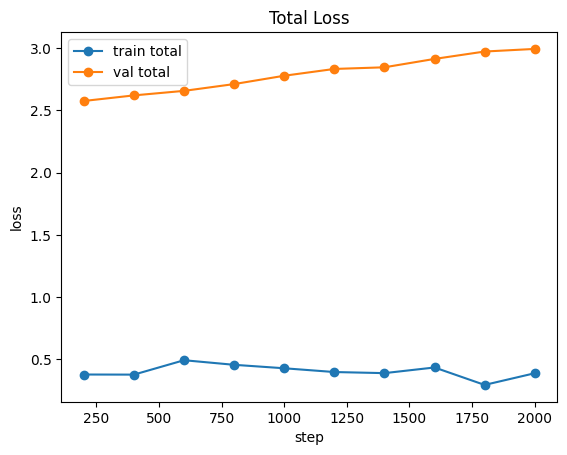

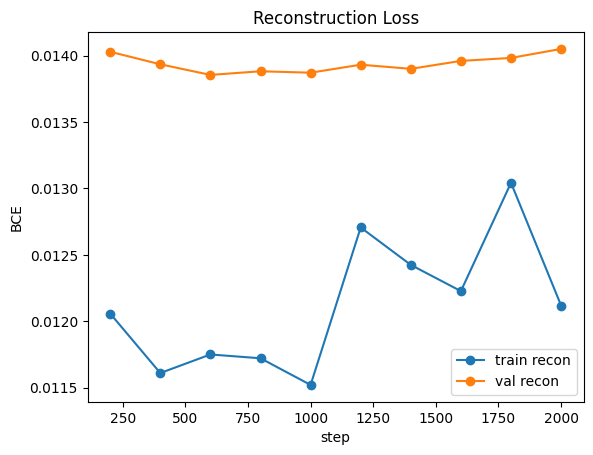

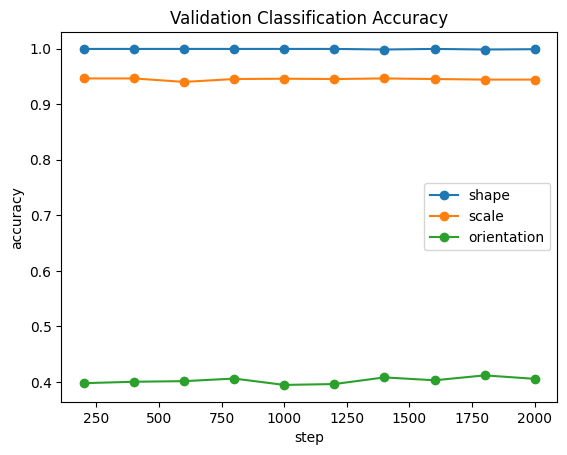

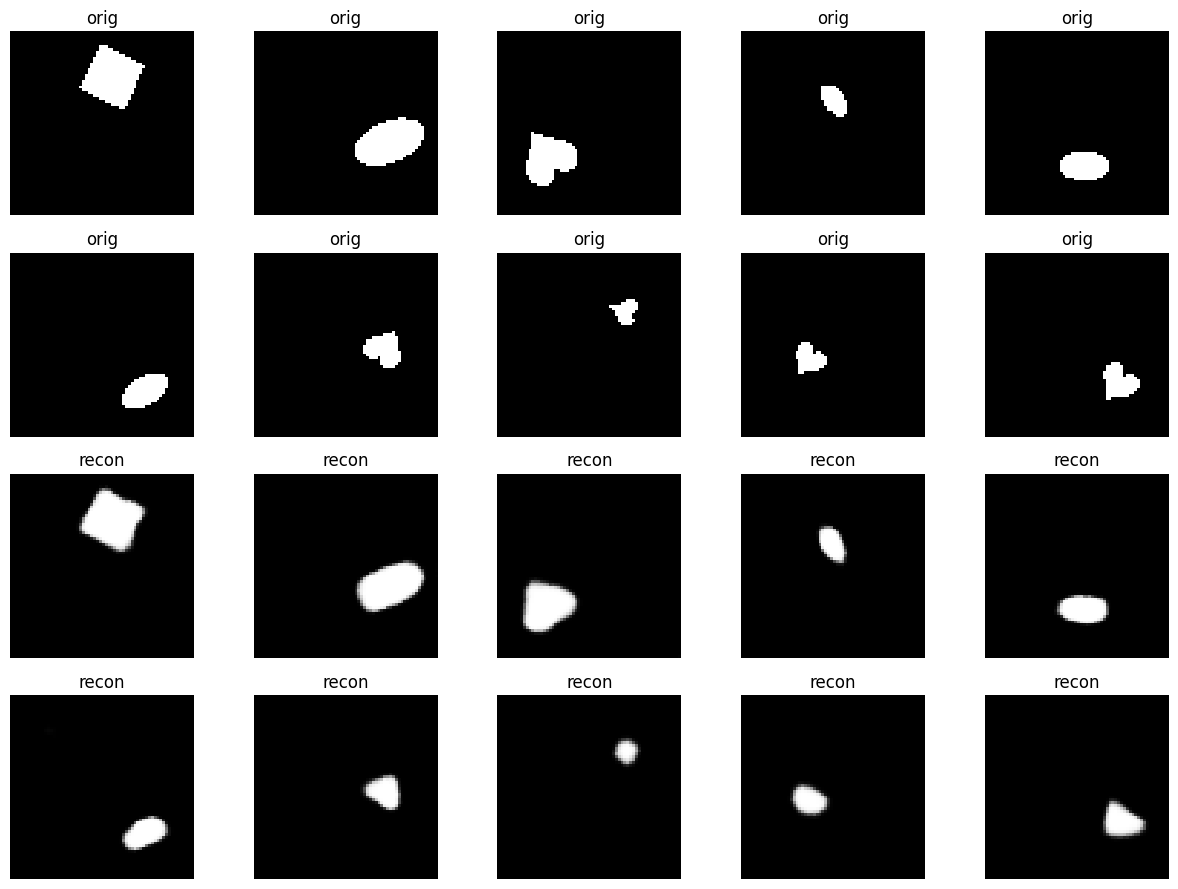

In [ ]:
# -----------------------------
# 6) Run LoRA
# -----------------------------
cfg = Config()

model_lora = SupervisedAutoencoderLoRA(
    rep_dim=cfg.rep_dim,
    lora_r=4,
    lora_alpha=8,   # alpha = 2r
)

model_lora = load_baseline_into_lora(
    lora_model=model_lora,
    baseline_model=model_fixed,
)

logs_lora = train_lora_from_baseline(
    model=model_lora,
    train_loader=train_loader_fixed,
    val_loader=val_loader_fixed,
    device=cfg.device,
    steps=2000,
    lr=1e-3,
    cls_weight=cfg.cls_weight,
    print_every=200,
)

plot_training_curves(logs_lora)
show_reconstructions(model_lora, val_loader_fixed, cfg.device, n_show=10)

LoRA feature shapes:
train_feats_lora: torch.Size([4000, 128])
val_feats_lora: torch.Size([1000, 128])
[Probe 1/20] train(shape/scale/orient)=0.252/0.204/0.038 | val(shape/scale/orient)=0.244/0.221/0.036
[Probe 2/20] train(shape/scale/orient)=0.266/0.219/0.041 | val(shape/scale/orient)=0.255/0.237/0.040
[Probe 3/20] train(shape/scale/orient)=0.286/0.235/0.043 | val(shape/scale/orient)=0.277/0.243/0.043
[Probe 4/20] train(shape/scale/orient)=0.308/0.250/0.050 | val(shape/scale/orient)=0.300/0.266/0.046
[Probe 5/20] train(shape/scale/orient)=0.338/0.266/0.058 | val(shape/scale/orient)=0.335/0.277/0.052
[Probe 6/20] train(shape/scale/orient)=0.372/0.284/0.064 | val(shape/scale/orient)=0.373/0.295/0.054
[Probe 7/20] train(shape/scale/orient)=0.408/0.301/0.069 | val(shape/scale/orient)=0.401/0.316/0.060
[Probe 8/20] train(shape/scale/orient)=0.449/0.321/0.078 | val(shape/scale/orient)=0.432/0.322/0.072
[Probe 9/20] train(shape/scale/orient)=0.479/0.344/0.083 | val(shape/scale/orient)=0.465/

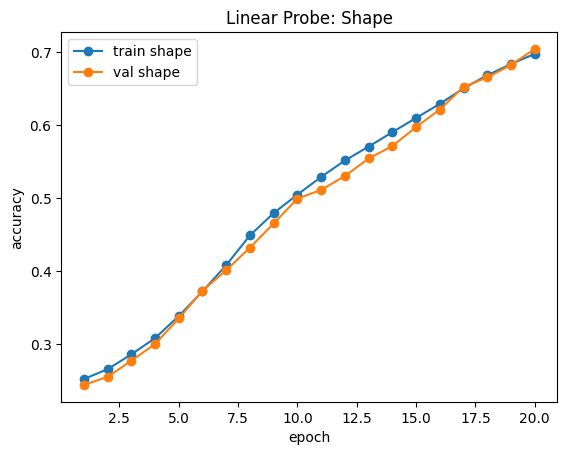

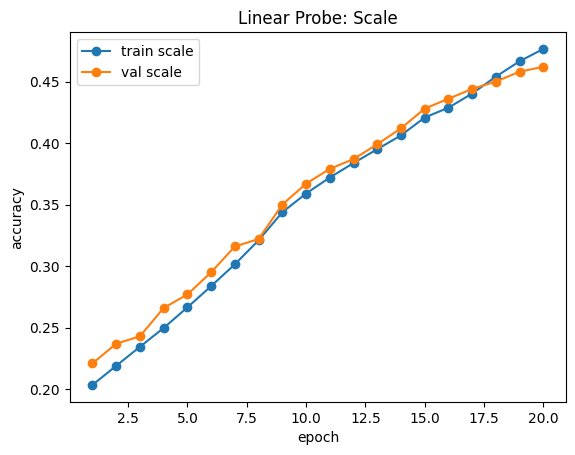

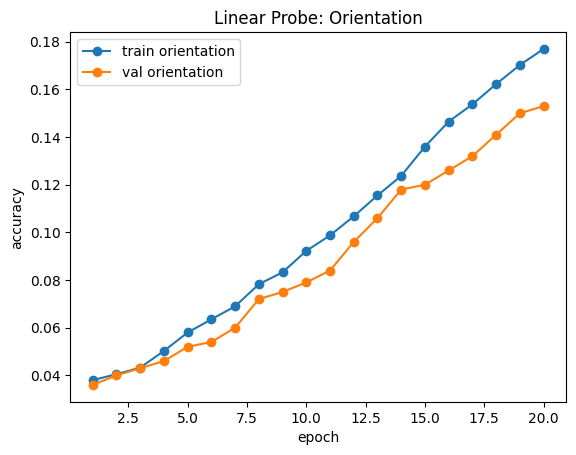


=== LORA SUPERPOSITION ANALYSIS ===


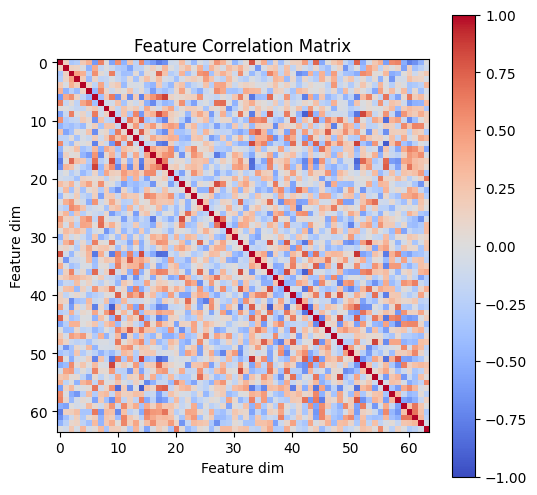

Mean |off-diagonal correlation|: 0.2832


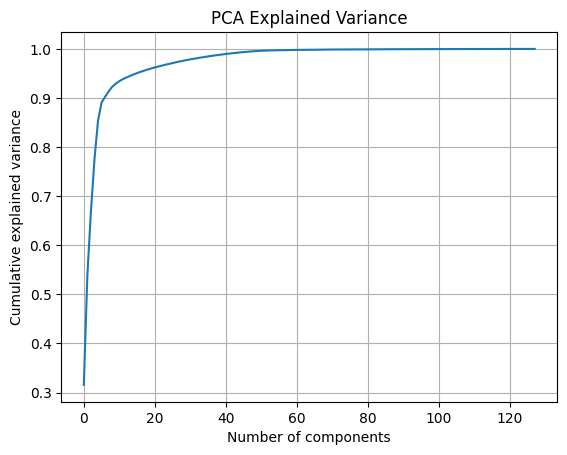

Top 10 components explain: 0.9291
Top 20 components explain: 0.9602


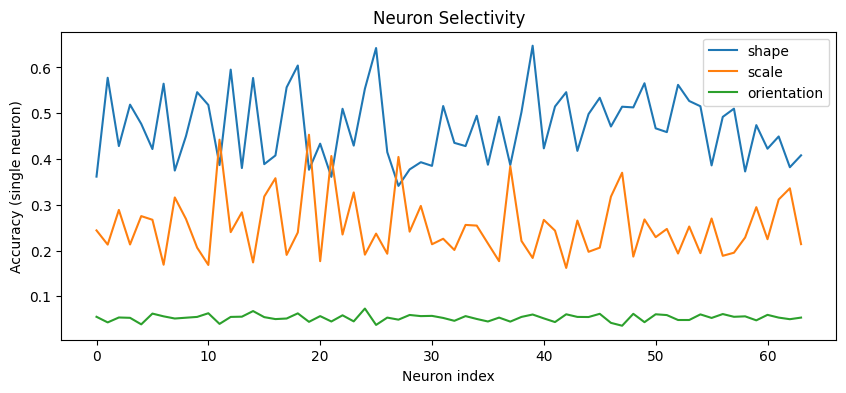


Top neurons per factor:
shape: max=0.647
scale: max=0.453
orientation: max=0.073
LoRA superposition score: 0.2832

========== LORA FINAL RESULTS ==========
Probe Shape       train=0.6973 val=0.7040
Probe Scale       train=0.4765 val=0.4620
Probe Orientation train=0.1770 val=0.1530


In [ ]:
# -----------------------------
# 7) LoRA probes + superposition analysis
# -----------------------------
train_feats_lora, train_targets_lora = extract_features(
    model_lora.encoder,
    train_loader_fixed,
    cfg.device,
    max_samples=4000,
)

val_feats_lora, val_targets_lora = extract_features(
    model_lora.encoder,
    val_loader_fixed,
    cfg.device,
    max_samples=1000,
)

print("LoRA feature shapes:")
print("train_feats_lora:", train_feats_lora.shape)
print("val_feats_lora:", val_feats_lora.shape)

probe_lora, probe_logs_lora = train_linear_probe(
    train_feats=train_feats_lora,
    train_targets=train_targets_lora,
    val_feats=val_feats_lora,
    val_targets=val_targets_lora,
    device=cfg.device,
    epochs=cfg.probe_epochs,
    lr=cfg.probe_lr,
)

plot_probe_curves(probe_logs_lora)

print("\n=== LORA SUPERPOSITION ANALYSIS ===")
corr_lora = plot_feature_correlation(train_feats_lora)
plot_pca_variance(train_feats_lora)
neuron_selectivity(train_feats_lora, train_targets_lora)

print(f"LoRA superposition score: {superposition_score(corr_lora):.4f}")

print("\n========== LORA FINAL RESULTS ==========")
print(f"Probe Shape       train={probe_logs_lora['train_acc_shape'][-1]:.4f} val={probe_logs_lora['val_acc_shape'][-1]:.4f}")
print(f"Probe Scale       train={probe_logs_lora['train_acc_scale'][-1]:.4f} val={probe_logs_lora['val_acc_scale'][-1]:.4f}")
print(f"Probe Orientation train={probe_logs_lora['train_acc_orientation'][-1]:.4f} val={probe_logs_lora['val_acc_orientation'][-1]:.4f}")

Trainable params: 8,497 / 879,890 (0.97%)
[LoRA] step 200/2000 train_total=0.5400 (recon=0.0122, cls=0.5278) | val_acc(shape/scale/orient)=0.999/0.945/0.409
[LoRA] step 400/2000 train_total=0.5068 (recon=0.0124, cls=0.4944) | val_acc(shape/scale/orient)=0.999/0.944/0.405
[LoRA] step 600/2000 train_total=0.4943 (recon=0.0115, cls=0.4827) | val_acc(shape/scale/orient)=0.999/0.943/0.395
[LoRA] step 800/2000 train_total=0.4537 (recon=0.0126, cls=0.4411) | val_acc(shape/scale/orient)=0.999/0.944/0.397
[LoRA] step 1000/2000 train_total=0.4144 (recon=0.0126, cls=0.4018) | val_acc(shape/scale/orient)=0.998/0.944/0.398
[LoRA] step 1200/2000 train_total=0.4130 (recon=0.0120, cls=0.4010) | val_acc(shape/scale/orient)=0.999/0.942/0.401
[LoRA] step 1400/2000 train_total=0.5172 (recon=0.0120, cls=0.5052) | val_acc(shape/scale/orient)=0.999/0.944/0.400
[LoRA] step 1600/2000 train_total=0.3257 (recon=0.0124, cls=0.3132) | val_acc(shape/scale/orient)=0.999/0.945/0.407
[LoRA] step 1800/2000 train_total=

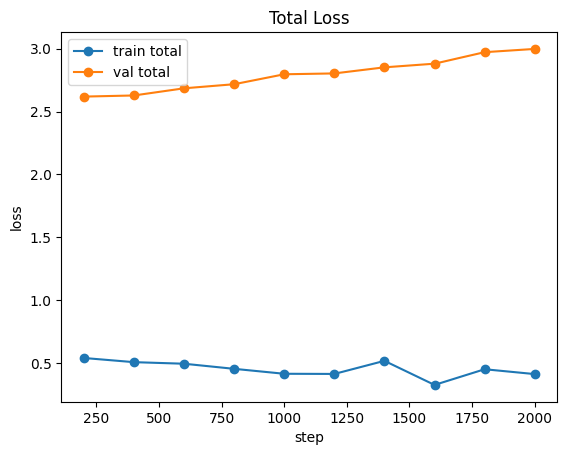

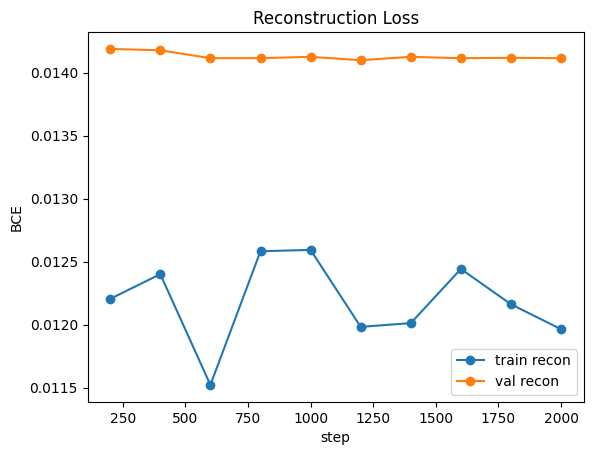

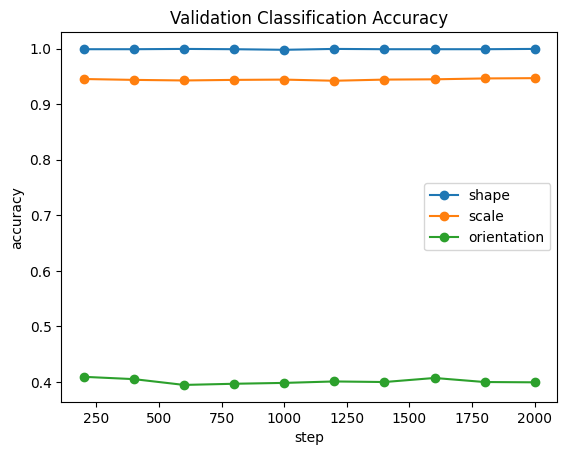

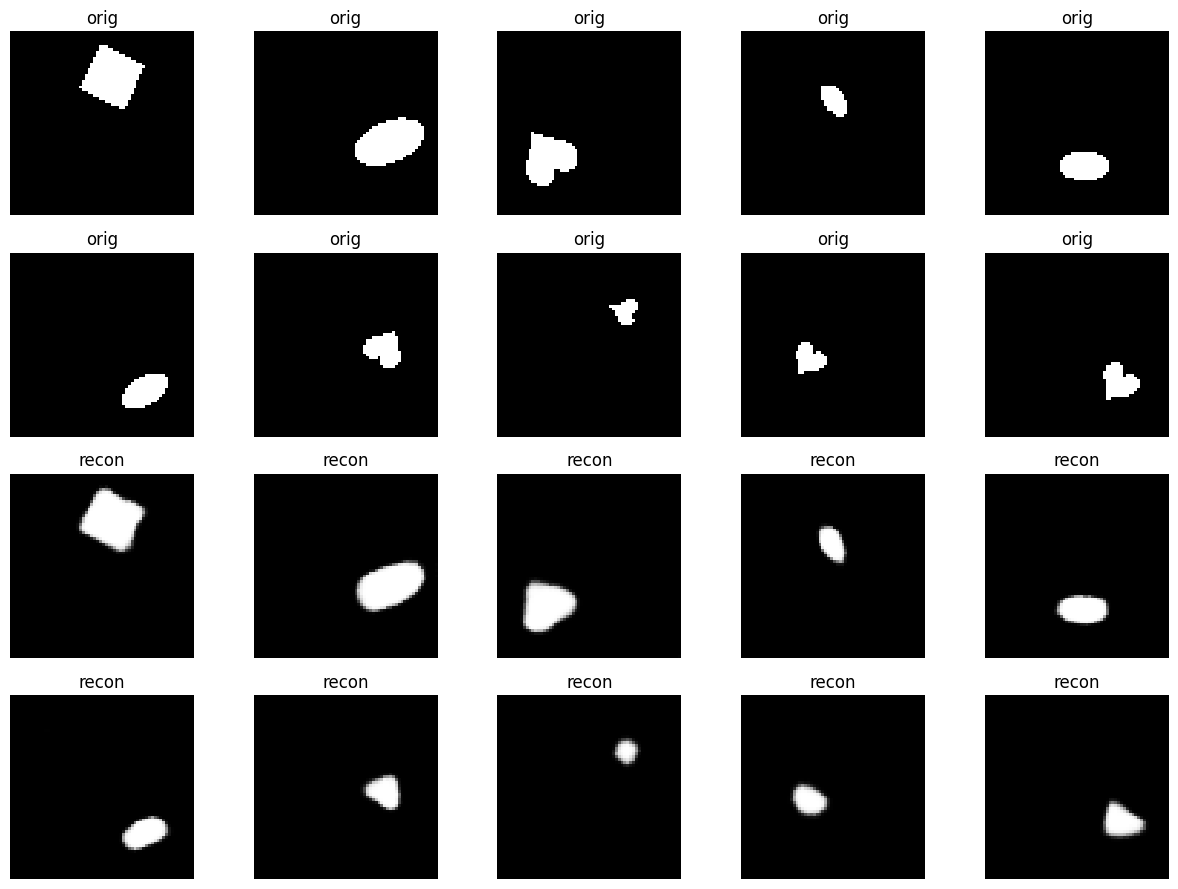

LoRA feature shapes:
train_feats_lora: torch.Size([4000, 128])
val_feats_lora: torch.Size([1000, 128])
[Probe 1/20] train(shape/scale/orient)=0.312/0.174/0.036 | val(shape/scale/orient)=0.285/0.175/0.031
[Probe 2/20] train(shape/scale/orient)=0.324/0.194/0.042 | val(shape/scale/orient)=0.300/0.192/0.035
[Probe 3/20] train(shape/scale/orient)=0.333/0.213/0.049 | val(shape/scale/orient)=0.314/0.215/0.045
[Probe 4/20] train(shape/scale/orient)=0.349/0.233/0.058 | val(shape/scale/orient)=0.332/0.238/0.057
[Probe 5/20] train(shape/scale/orient)=0.366/0.253/0.068 | val(shape/scale/orient)=0.349/0.263/0.069
[Probe 6/20] train(shape/scale/orient)=0.389/0.271/0.078 | val(shape/scale/orient)=0.366/0.279/0.078
[Probe 7/20] train(shape/scale/orient)=0.413/0.289/0.086 | val(shape/scale/orient)=0.388/0.293/0.090
[Probe 8/20] train(shape/scale/orient)=0.436/0.310/0.094 | val(shape/scale/orient)=0.421/0.305/0.100
[Probe 9/20] train(shape/scale/orient)=0.468/0.322/0.105 | val(shape/scale/orient)=0.460/

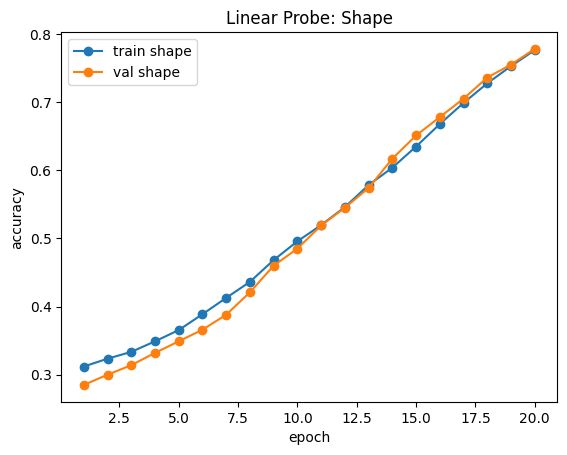

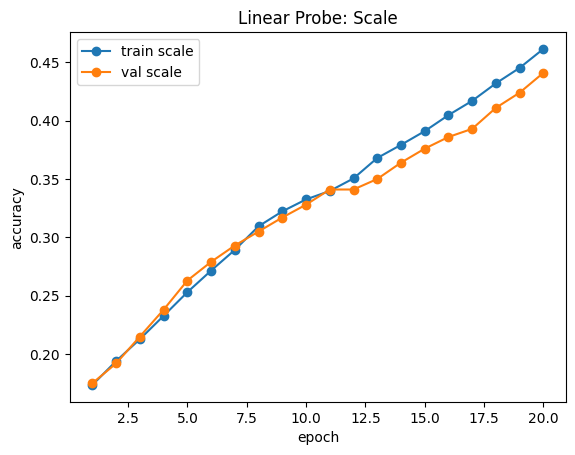

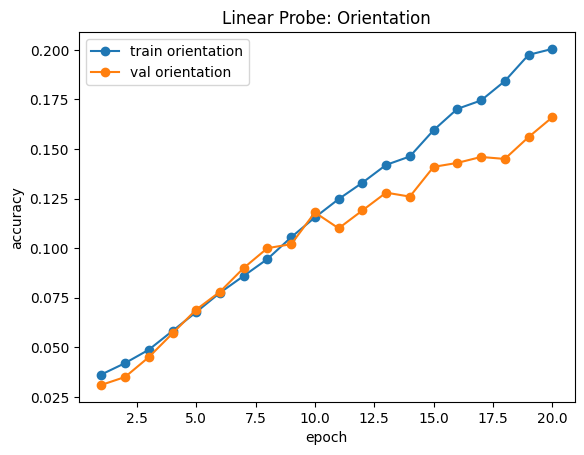


=== LORA SUPERPOSITION ANALYSIS ===


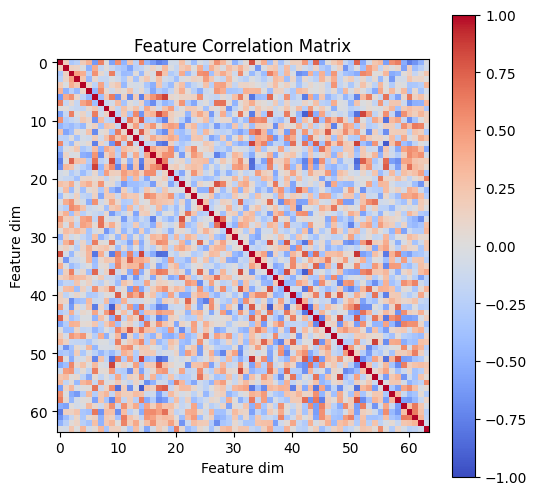

Mean |off-diagonal correlation|: 0.2820


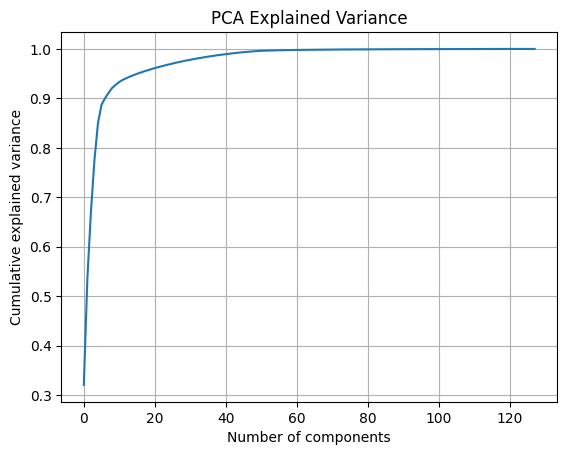

Top 10 components explain: 0.9277
Top 20 components explain: 0.9591


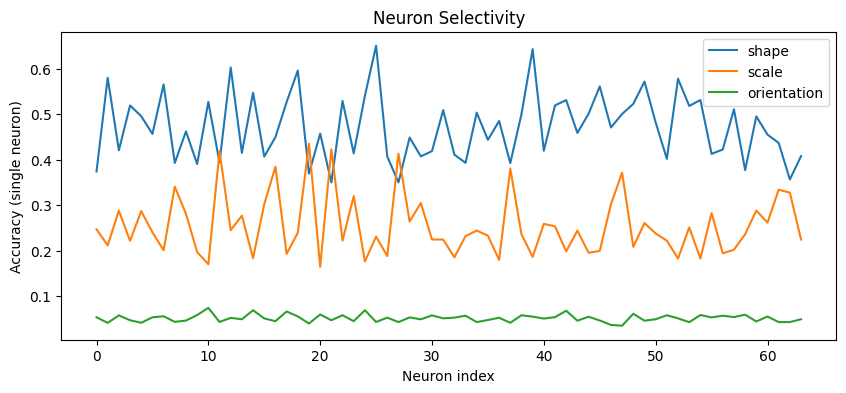


Top neurons per factor:
shape: max=0.650
scale: max=0.435
orientation: max=0.074
LoRA superposition score: 0.2820

========== LORA FINAL RESULTS ==========
Probe Shape       train=0.7763 val=0.7780
Probe Scale       train=0.4615 val=0.4410
Probe Orientation train=0.2005 val=0.1660


In [ ]:
# -----------------------------
# 6) Run LoRA
# -----------------------------
cfg = Config()

model_lora = SupervisedAutoencoderLoRA(
    rep_dim=cfg.rep_dim,
    lora_r=1,
    lora_alpha=2,   # alpha = 2r
)

model_lora = load_baseline_into_lora(
    lora_model=model_lora,
    baseline_model=model_fixed,
)

logs_lora = train_lora_from_baseline(
    model=model_lora,
    train_loader=train_loader_fixed,
    val_loader=val_loader_fixed,
    device=cfg.device,
    steps=2000,
    lr=1e-3,
    cls_weight=cfg.cls_weight,
    print_every=200,
)

plot_training_curves(logs_lora)
show_reconstructions(model_lora, val_loader_fixed, cfg.device, n_show=10)

train_feats_lora, train_targets_lora = extract_features(
    model_lora.encoder,
    train_loader_fixed,
    cfg.device,
    max_samples=4000,
)

val_feats_lora, val_targets_lora = extract_features(
    model_lora.encoder,
    val_loader_fixed,
    cfg.device,
    max_samples=1000,
)

print("LoRA feature shapes:")
print("train_feats_lora:", train_feats_lora.shape)
print("val_feats_lora:", val_feats_lora.shape)

probe_lora, probe_logs_lora = train_linear_probe(
    train_feats=train_feats_lora,
    train_targets=train_targets_lora,
    val_feats=val_feats_lora,
    val_targets=val_targets_lora,
    device=cfg.device,
    epochs=cfg.probe_epochs,
    lr=cfg.probe_lr,
)

plot_probe_curves(probe_logs_lora)

print("\n=== LORA SUPERPOSITION ANALYSIS ===")
corr_lora = plot_feature_correlation(train_feats_lora)
plot_pca_variance(train_feats_lora)
neuron_selectivity(train_feats_lora, train_targets_lora)

print(f"LoRA superposition score: {superposition_score(corr_lora):.4f}")

print("\n========== LORA FINAL RESULTS ==========")
print(f"Probe Shape       train={probe_logs_lora['train_acc_shape'][-1]:.4f} val={probe_logs_lora['val_acc_shape'][-1]:.4f}")
print(f"Probe Scale       train={probe_logs_lora['train_acc_scale'][-1]:.4f} val={probe_logs_lora['val_acc_scale'][-1]:.4f}")
print(f"Probe Orientation train={probe_logs_lora['train_acc_orientation'][-1]:.4f} val={probe_logs_lora['val_acc_orientation'][-1]:.4f}")

Trainable params: 10,673 / 882,066 (1.21%)
[LoRA] step 200/2000 train_total=0.6209 (recon=0.0116, cls=0.6092) | val_acc(shape/scale/orient)=0.999/0.947/0.392
[LoRA] step 400/2000 train_total=0.4839 (recon=0.0125, cls=0.4713) | val_acc(shape/scale/orient)=0.999/0.946/0.396
[LoRA] step 600/2000 train_total=0.3774 (recon=0.0118, cls=0.3656) | val_acc(shape/scale/orient)=0.998/0.946/0.397
[LoRA] step 800/2000 train_total=0.3173 (recon=0.0118, cls=0.3056) | val_acc(shape/scale/orient)=0.998/0.942/0.403
[LoRA] step 1000/2000 train_total=0.3338 (recon=0.0129, cls=0.3210) | val_acc(shape/scale/orient)=0.998/0.938/0.398
[LoRA] step 1200/2000 train_total=0.3483 (recon=0.0121, cls=0.3363) | val_acc(shape/scale/orient)=0.999/0.947/0.391
[LoRA] step 1400/2000 train_total=0.3372 (recon=0.0117, cls=0.3254) | val_acc(shape/scale/orient)=0.999/0.946/0.402
[LoRA] step 1600/2000 train_total=0.3092 (recon=0.0125, cls=0.2966) | val_acc(shape/scale/orient)=0.999/0.944/0.406
[LoRA] step 1800/2000 train_total

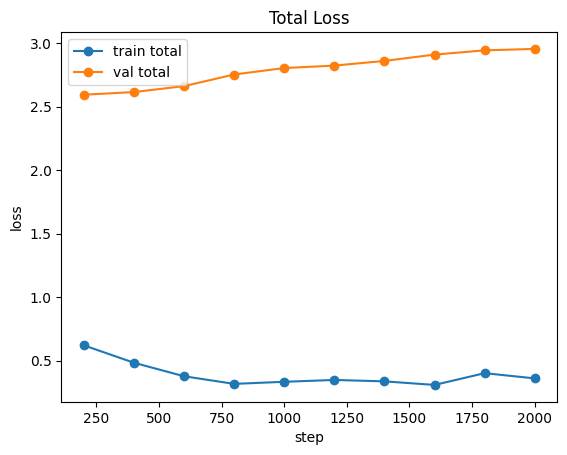

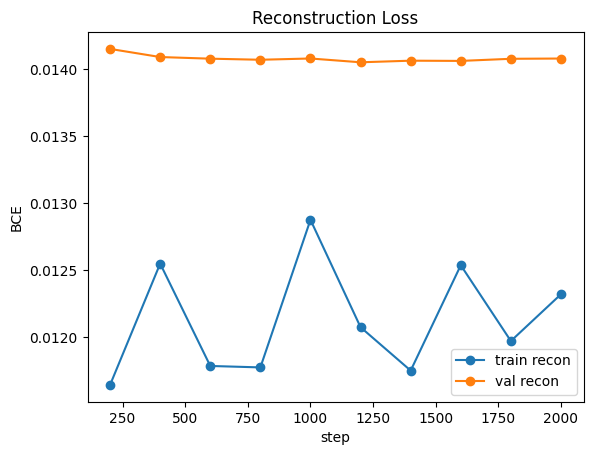

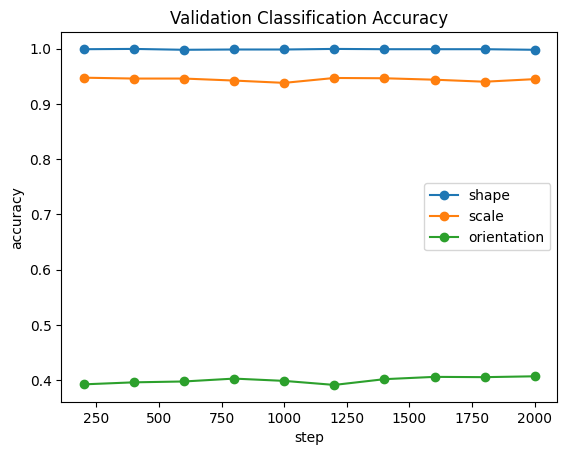

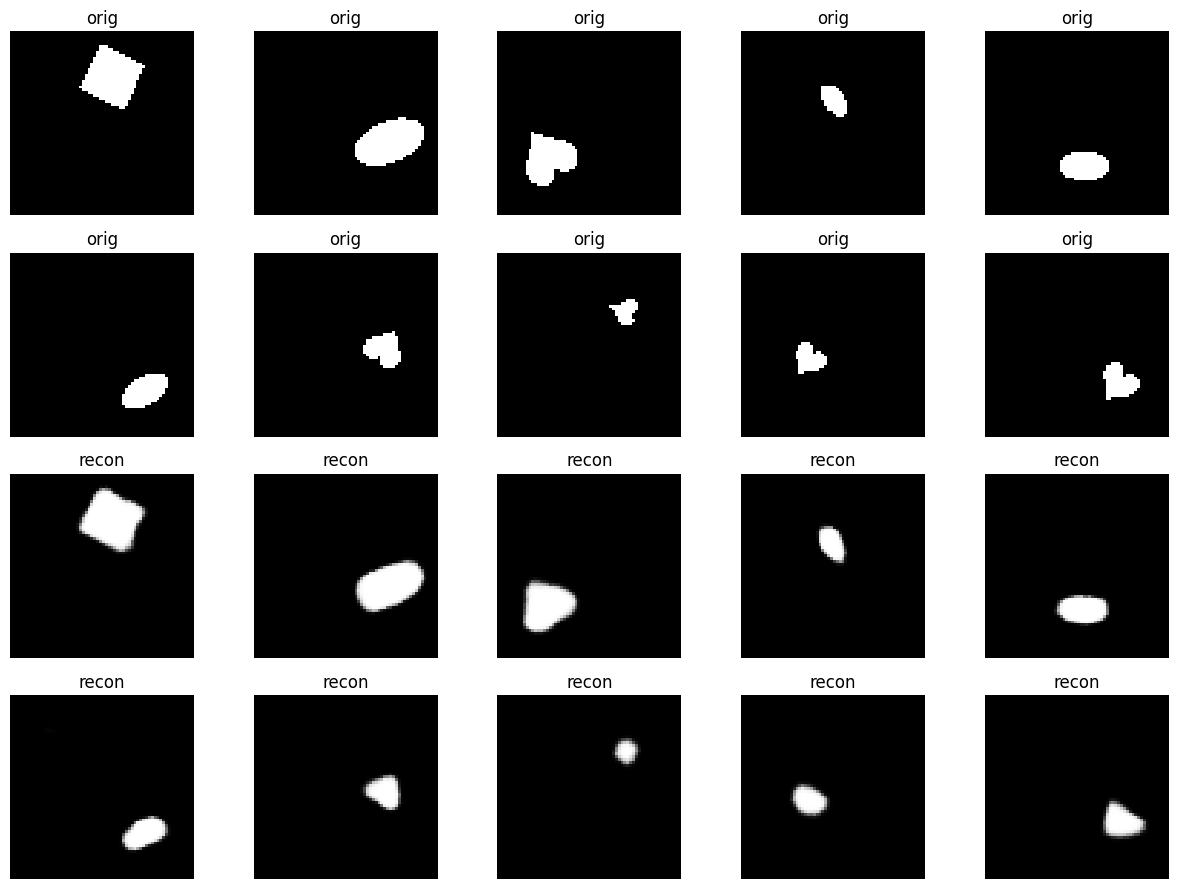

LoRA feature shapes:
train_feats_lora: torch.Size([4000, 128])
val_feats_lora: torch.Size([1000, 128])
[Probe 1/20] train(shape/scale/orient)=0.354/0.232/0.034 | val(shape/scale/orient)=0.348/0.237/0.030
[Probe 2/20] train(shape/scale/orient)=0.382/0.247/0.040 | val(shape/scale/orient)=0.371/0.249/0.039
[Probe 3/20] train(shape/scale/orient)=0.409/0.265/0.051 | val(shape/scale/orient)=0.409/0.264/0.040
[Probe 4/20] train(shape/scale/orient)=0.441/0.283/0.060 | val(shape/scale/orient)=0.443/0.279/0.056
[Probe 5/20] train(shape/scale/orient)=0.485/0.296/0.070 | val(shape/scale/orient)=0.479/0.292/0.072
[Probe 6/20] train(shape/scale/orient)=0.519/0.306/0.083 | val(shape/scale/orient)=0.513/0.294/0.083
[Probe 7/20] train(shape/scale/orient)=0.554/0.315/0.094 | val(shape/scale/orient)=0.545/0.318/0.088
[Probe 8/20] train(shape/scale/orient)=0.590/0.327/0.103 | val(shape/scale/orient)=0.571/0.330/0.098
[Probe 9/20] train(shape/scale/orient)=0.615/0.336/0.112 | val(shape/scale/orient)=0.590/

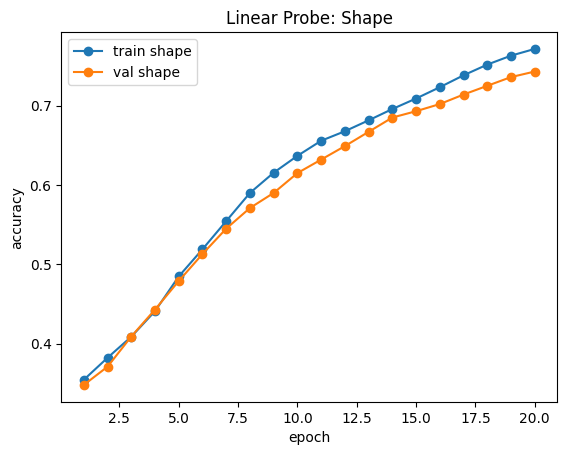

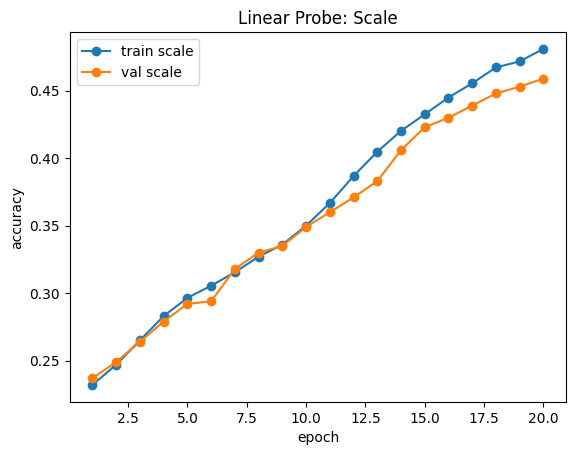

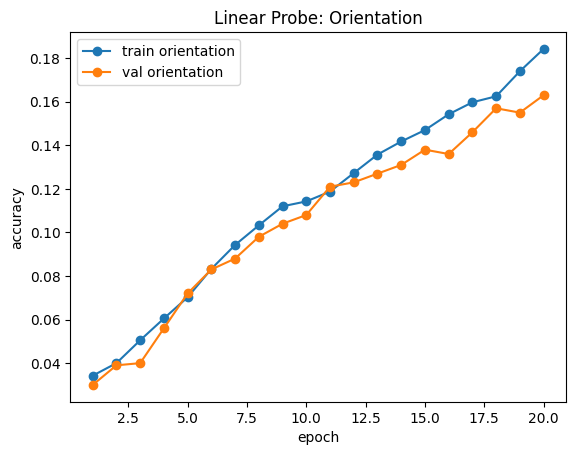


=== LORA SUPERPOSITION ANALYSIS ===


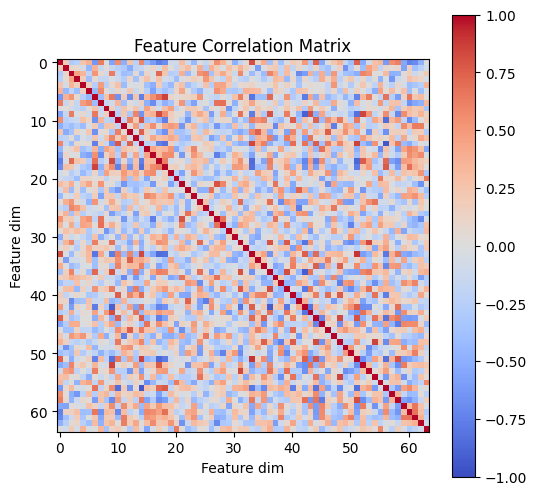

Mean |off-diagonal correlation|: 0.2853


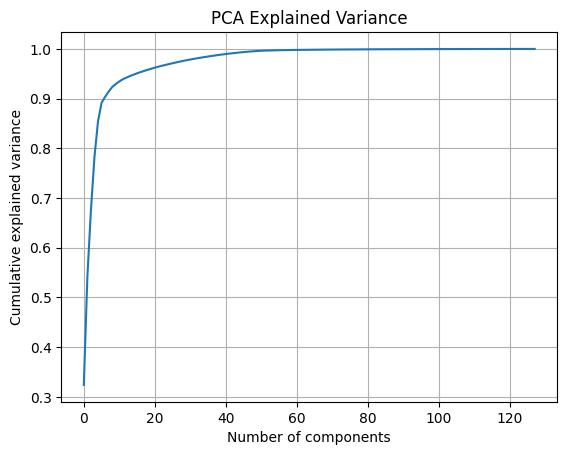

Top 10 components explain: 0.9295
Top 20 components explain: 0.9602


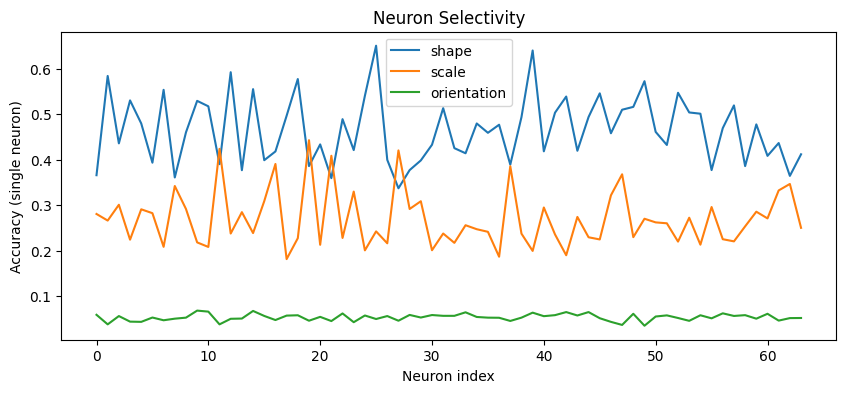


Top neurons per factor:
shape: max=0.651
scale: max=0.443
orientation: max=0.068
LoRA superposition score: 0.2853

========== LORA FINAL RESULTS ==========
Probe Shape       train=0.7715 val=0.7430
Probe Scale       train=0.4810 val=0.4590
Probe Orientation train=0.1842 val=0.1630


In [ ]:
# -----------------------------
# 6) Run LoRA
# -----------------------------
cfg = Config()

model_lora = SupervisedAutoencoderLoRA(
    rep_dim=cfg.rep_dim,
    lora_r=2,
    lora_alpha=4,   # alpha = 2r
)

model_lora = load_baseline_into_lora(
    lora_model=model_lora,
    baseline_model=model_fixed,
)

logs_lora = train_lora_from_baseline(
    model=model_lora,
    train_loader=train_loader_fixed,
    val_loader=val_loader_fixed,
    device=cfg.device,
    steps=2000,
    lr=1e-3,
    cls_weight=cfg.cls_weight,
    print_every=200,
)

plot_training_curves(logs_lora)
show_reconstructions(model_lora, val_loader_fixed, cfg.device, n_show=10)

train_feats_lora, train_targets_lora = extract_features(
    model_lora.encoder,
    train_loader_fixed,
    cfg.device,
    max_samples=4000,
)

val_feats_lora, val_targets_lora = extract_features(
    model_lora.encoder,
    val_loader_fixed,
    cfg.device,
    max_samples=1000,
)

print("LoRA feature shapes:")
print("train_feats_lora:", train_feats_lora.shape)
print("val_feats_lora:", val_feats_lora.shape)

probe_lora, probe_logs_lora = train_linear_probe(
    train_feats=train_feats_lora,
    train_targets=train_targets_lora,
    val_feats=val_feats_lora,
    val_targets=val_targets_lora,
    device=cfg.device,
    epochs=cfg.probe_epochs,
    lr=cfg.probe_lr,
)

plot_probe_curves(probe_logs_lora)

print("\n=== LORA SUPERPOSITION ANALYSIS ===")
corr_lora = plot_feature_correlation(train_feats_lora)
plot_pca_variance(train_feats_lora)
neuron_selectivity(train_feats_lora, train_targets_lora)

print(f"LoRA superposition score: {superposition_score(corr_lora):.4f}")

print("\n========== LORA FINAL RESULTS ==========")
print(f"Probe Shape       train={probe_logs_lora['train_acc_shape'][-1]:.4f} val={probe_logs_lora['val_acc_shape'][-1]:.4f}")
print(f"Probe Scale       train={probe_logs_lora['train_acc_scale'][-1]:.4f} val={probe_logs_lora['val_acc_scale'][-1]:.4f}")
print(f"Probe Orientation train={probe_logs_lora['train_acc_orientation'][-1]:.4f} val={probe_logs_lora['val_acc_orientation'][-1]:.4f}")

Trainable params: 23,729 / 895,122 (2.65%)
[LoRA] step 200/2000 train_total=0.4481 (recon=0.0124, cls=0.4357) | val_acc(shape/scale/orient)=0.997/0.941/0.406
[LoRA] step 400/2000 train_total=0.4766 (recon=0.0116, cls=0.4650) | val_acc(shape/scale/orient)=0.999/0.943/0.399
[LoRA] step 600/2000 train_total=0.4004 (recon=0.0118, cls=0.3885) | val_acc(shape/scale/orient)=0.999/0.942/0.402
[LoRA] step 800/2000 train_total=0.5248 (recon=0.0115, cls=0.5133) | val_acc(shape/scale/orient)=0.999/0.945/0.397
[LoRA] step 1000/2000 train_total=0.3219 (recon=0.0125, cls=0.3094) | val_acc(shape/scale/orient)=0.999/0.945/0.396
[LoRA] step 1200/2000 train_total=0.3826 (recon=0.0109, cls=0.3716) | val_acc(shape/scale/orient)=0.999/0.946/0.399
[LoRA] step 1400/2000 train_total=0.4224 (recon=0.0119, cls=0.4105) | val_acc(shape/scale/orient)=0.998/0.942/0.406
[LoRA] step 1600/2000 train_total=0.3499 (recon=0.0119, cls=0.3380) | val_acc(shape/scale/orient)=0.999/0.947/0.405
[LoRA] step 1800/2000 train_total

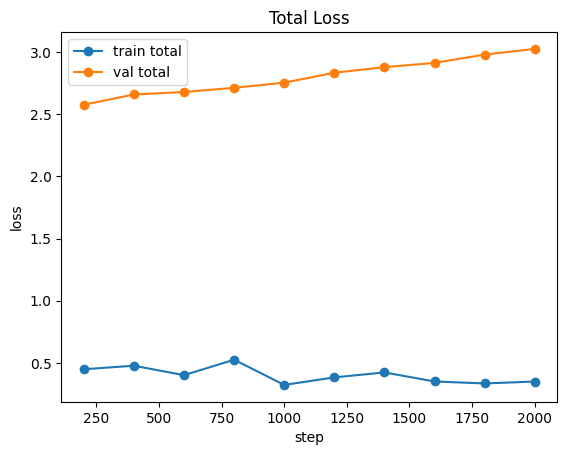

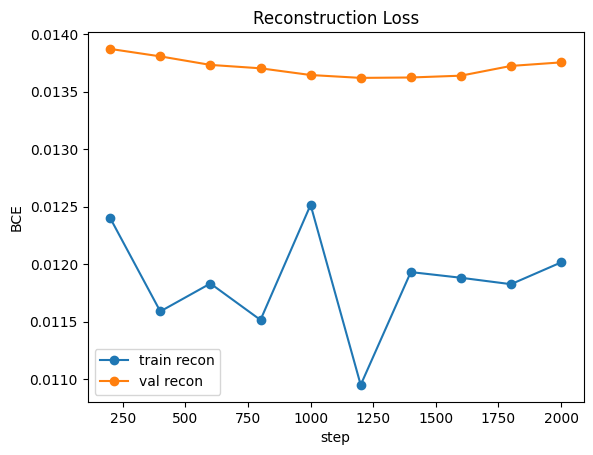

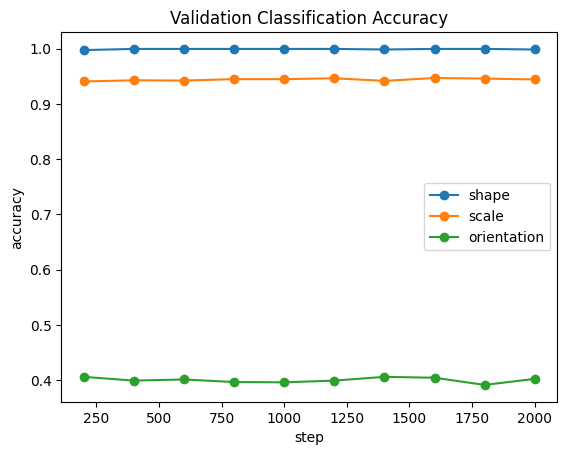

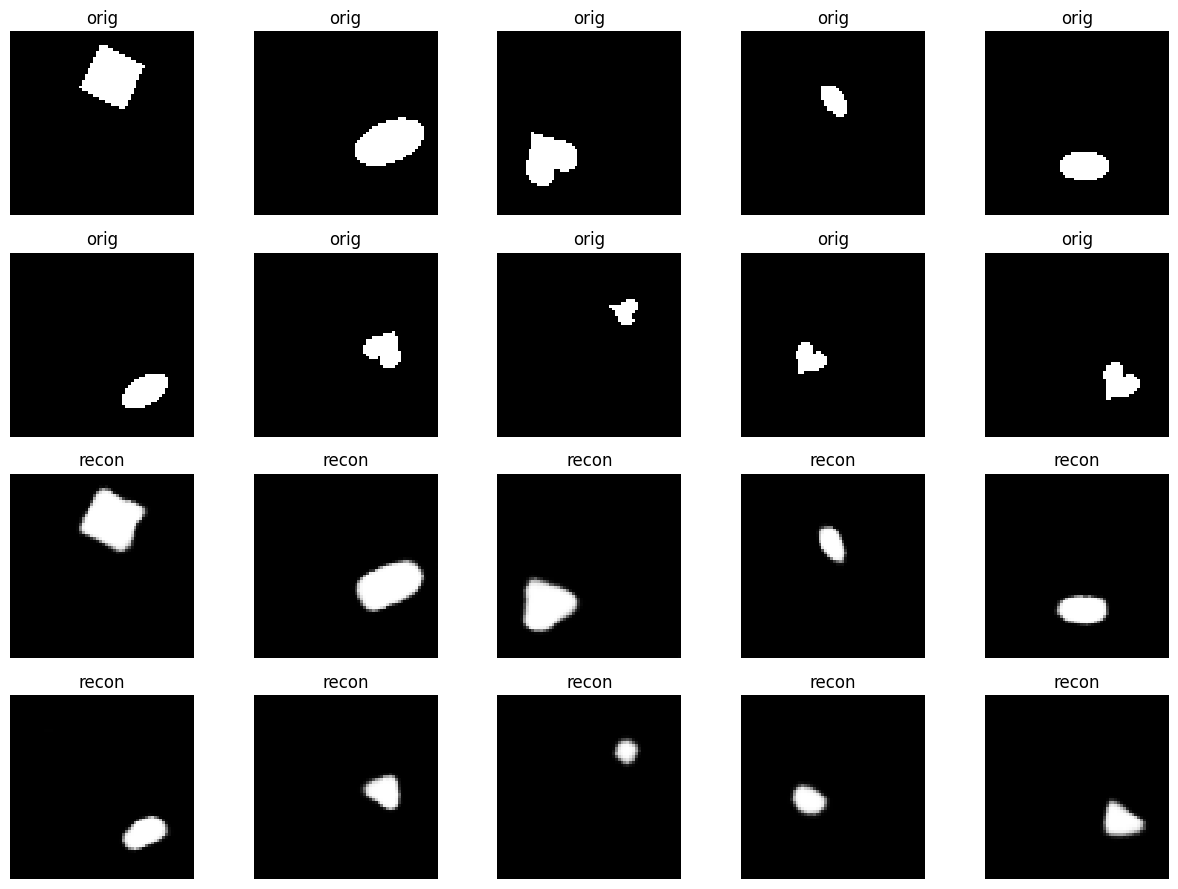

LoRA feature shapes:
train_feats_lora: torch.Size([4000, 128])
val_feats_lora: torch.Size([1000, 128])
[Probe 1/20] train(shape/scale/orient)=0.296/0.176/0.028 | val(shape/scale/orient)=0.317/0.179/0.028
[Probe 2/20] train(shape/scale/orient)=0.308/0.187/0.032 | val(shape/scale/orient)=0.325/0.200/0.036
[Probe 3/20] train(shape/scale/orient)=0.323/0.200/0.038 | val(shape/scale/orient)=0.335/0.208/0.042
[Probe 4/20] train(shape/scale/orient)=0.340/0.214/0.049 | val(shape/scale/orient)=0.349/0.218/0.052
[Probe 5/20] train(shape/scale/orient)=0.360/0.235/0.058 | val(shape/scale/orient)=0.363/0.235/0.057
[Probe 6/20] train(shape/scale/orient)=0.380/0.264/0.067 | val(shape/scale/orient)=0.391/0.257/0.075
[Probe 7/20] train(shape/scale/orient)=0.405/0.292/0.077 | val(shape/scale/orient)=0.409/0.279/0.084
[Probe 8/20] train(shape/scale/orient)=0.427/0.312/0.085 | val(shape/scale/orient)=0.434/0.309/0.096
[Probe 9/20] train(shape/scale/orient)=0.451/0.330/0.096 | val(shape/scale/orient)=0.453/

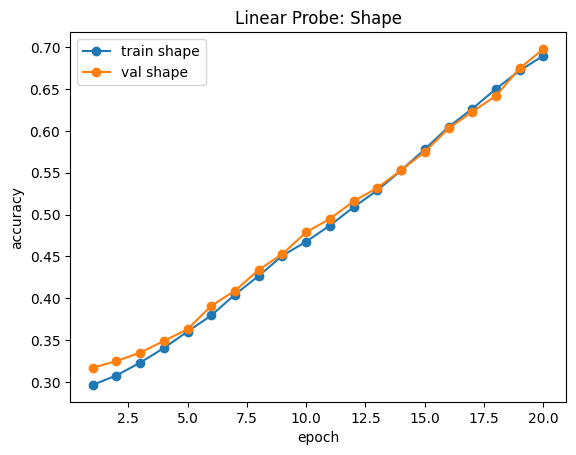

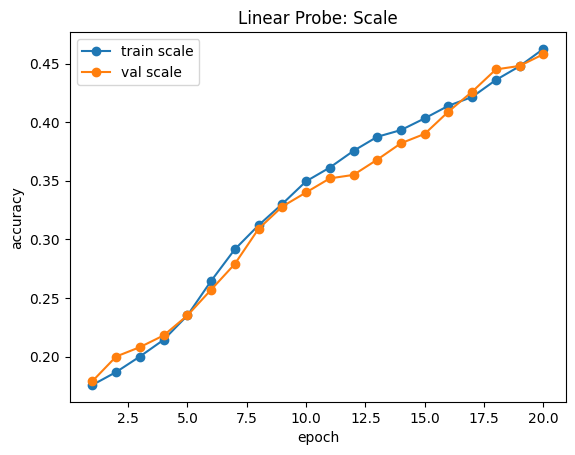

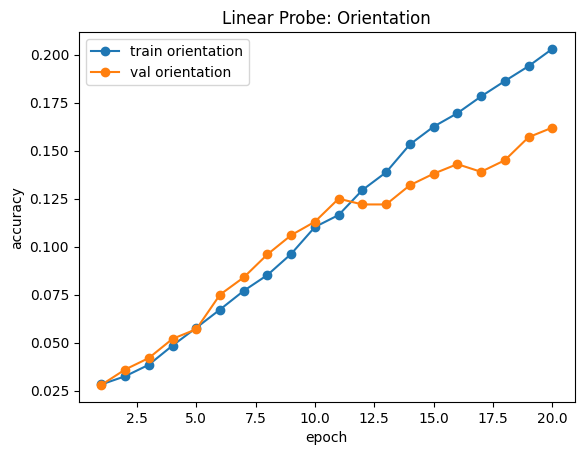


=== LORA SUPERPOSITION ANALYSIS ===


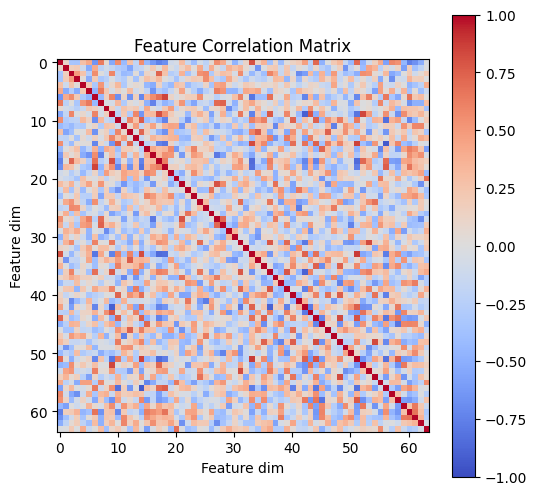

Mean |off-diagonal correlation|: 0.2832


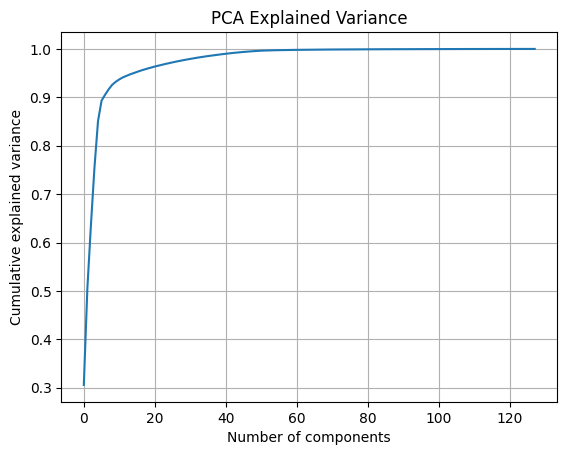

Top 10 components explain: 0.9321
Top 20 components explain: 0.9616


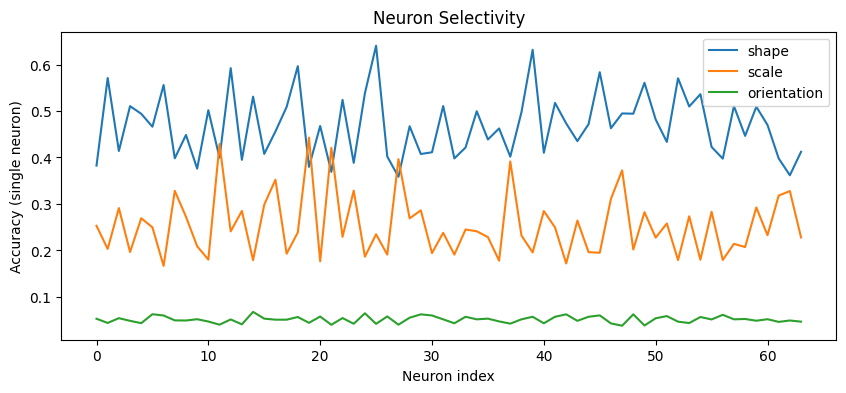


Top neurons per factor:
shape: max=0.640
scale: max=0.443
orientation: max=0.068
LoRA superposition score: 0.2832

========== LORA FINAL RESULTS ==========
Probe Shape       train=0.6900 val=0.6980
Probe Scale       train=0.4625 val=0.4580
Probe Orientation train=0.2030 val=0.1620


In [ ]:
# -----------------------------
# 6) Run LoRA
# -----------------------------
cfg = Config()

model_lora = SupervisedAutoencoderLoRA(
    rep_dim=cfg.rep_dim,
    lora_r=8,
    lora_alpha=16,   # alpha = 2r
)

model_lora = load_baseline_into_lora(
    lora_model=model_lora,
    baseline_model=model_fixed,
)

logs_lora = train_lora_from_baseline(
    model=model_lora,
    train_loader=train_loader_fixed,
    val_loader=val_loader_fixed,
    device=cfg.device,
    steps=2000,
    lr=1e-3,
    cls_weight=cfg.cls_weight,
    print_every=200,
)

plot_training_curves(logs_lora)
show_reconstructions(model_lora, val_loader_fixed, cfg.device, n_show=10)

train_feats_lora, train_targets_lora = extract_features(
    model_lora.encoder,
    train_loader_fixed,
    cfg.device,
    max_samples=4000,
)

val_feats_lora, val_targets_lora = extract_features(
    model_lora.encoder,
    val_loader_fixed,
    cfg.device,
    max_samples=1000,
)

print("LoRA feature shapes:")
print("train_feats_lora:", train_feats_lora.shape)
print("val_feats_lora:", val_feats_lora.shape)

probe_lora, probe_logs_lora = train_linear_probe(
    train_feats=train_feats_lora,
    train_targets=train_targets_lora,
    val_feats=val_feats_lora,
    val_targets=val_targets_lora,
    device=cfg.device,
    epochs=cfg.probe_epochs,
    lr=cfg.probe_lr,
)

plot_probe_curves(probe_logs_lora)

print("\n=== LORA SUPERPOSITION ANALYSIS ===")
corr_lora = plot_feature_correlation(train_feats_lora)
plot_pca_variance(train_feats_lora)
neuron_selectivity(train_feats_lora, train_targets_lora)

print(f"LoRA superposition score: {superposition_score(corr_lora):.4f}")

print("\n========== LORA FINAL RESULTS ==========")
print(f"Probe Shape       train={probe_logs_lora['train_acc_shape'][-1]:.4f} val={probe_logs_lora['val_acc_shape'][-1]:.4f}")
print(f"Probe Scale       train={probe_logs_lora['train_acc_scale'][-1]:.4f} val={probe_logs_lora['val_acc_scale'][-1]:.4f}")
print(f"Probe Orientation train={probe_logs_lora['train_acc_orientation'][-1]:.4f} val={probe_logs_lora['val_acc_orientation'][-1]:.4f}")

Trainable params: 41,137 / 912,530 (4.51%)
[LoRA] step 200/2000 train_total=0.3895 (recon=0.0123, cls=0.3773) | val_acc(shape/scale/orient)=0.999/0.943/0.402
[LoRA] step 400/2000 train_total=0.3461 (recon=0.0110, cls=0.3351) | val_acc(shape/scale/orient)=0.999/0.944/0.405
[LoRA] step 600/2000 train_total=0.4085 (recon=0.0119, cls=0.3966) | val_acc(shape/scale/orient)=0.999/0.942/0.405
[LoRA] step 800/2000 train_total=0.4225 (recon=0.0120, cls=0.4104) | val_acc(shape/scale/orient)=0.999/0.946/0.404
[LoRA] step 1000/2000 train_total=0.3686 (recon=0.0116, cls=0.3570) | val_acc(shape/scale/orient)=0.999/0.944/0.403
[LoRA] step 1200/2000 train_total=0.3431 (recon=0.0114, cls=0.3317) | val_acc(shape/scale/orient)=0.998/0.947/0.399
[LoRA] step 1400/2000 train_total=0.4100 (recon=0.0116, cls=0.3984) | val_acc(shape/scale/orient)=0.998/0.947/0.408
[LoRA] step 1600/2000 train_total=0.2792 (recon=0.0113, cls=0.2679) | val_acc(shape/scale/orient)=0.999/0.943/0.403
[LoRA] step 1800/2000 train_total

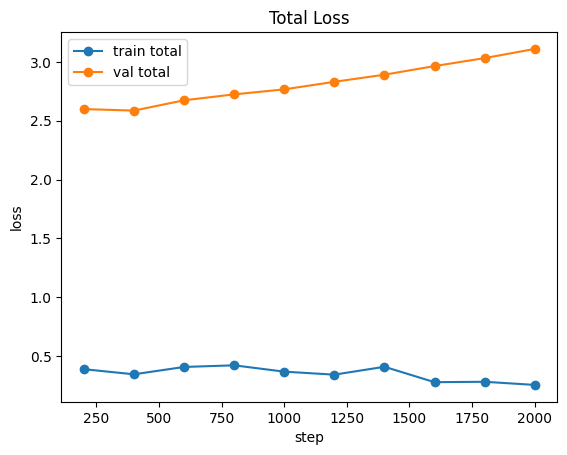

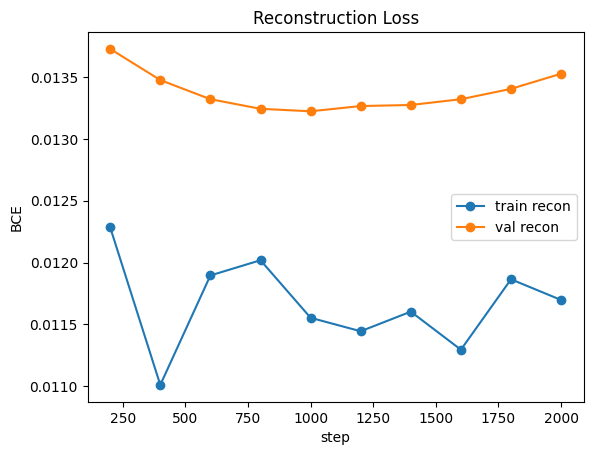

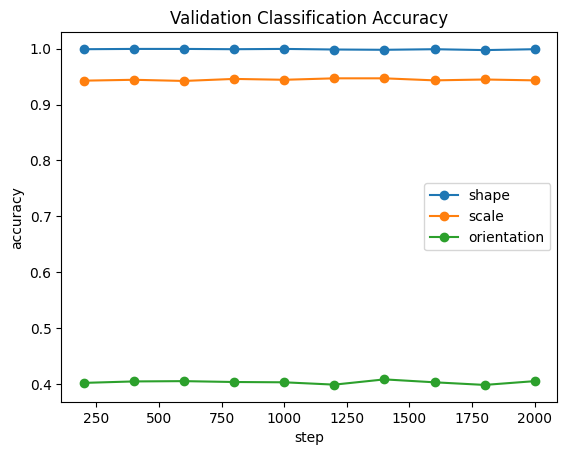

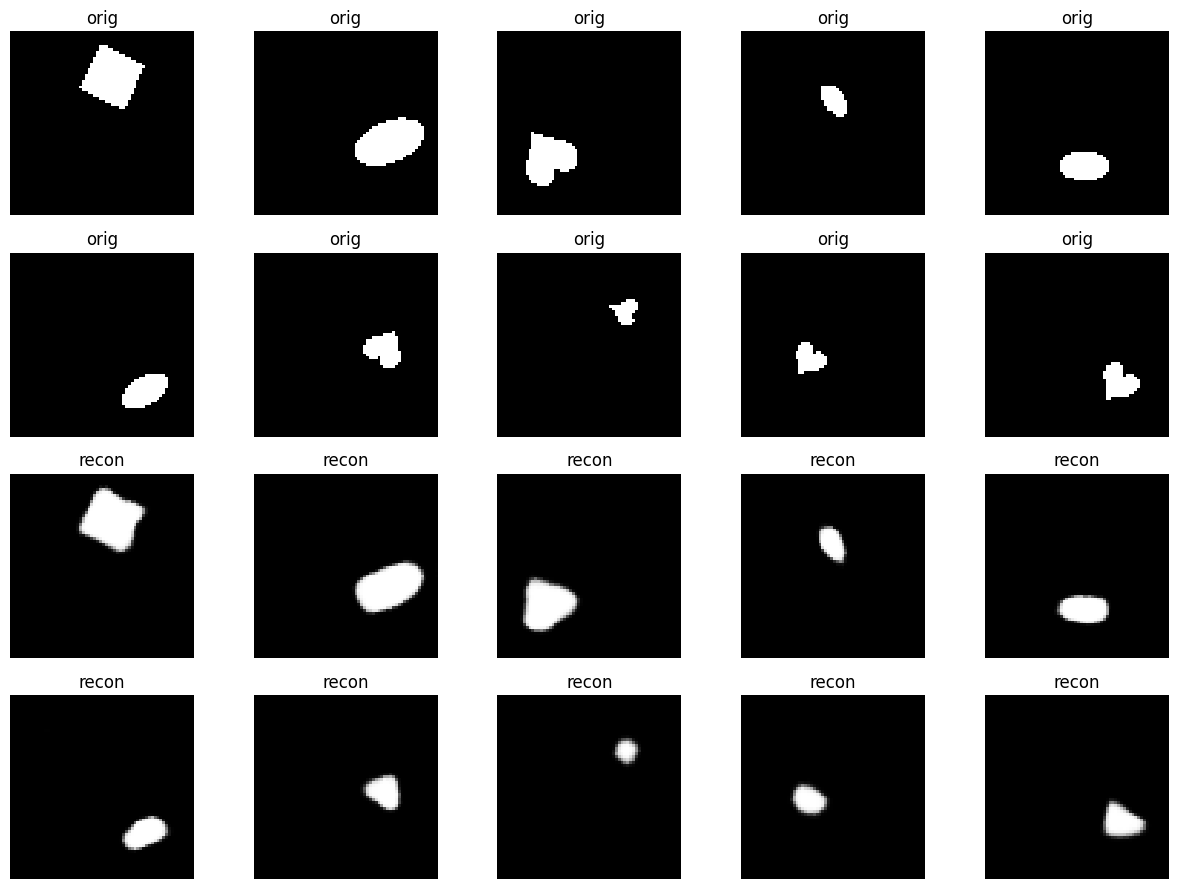

LoRA feature shapes:
train_feats_lora: torch.Size([4000, 128])
val_feats_lora: torch.Size([1000, 128])
[Probe 1/20] train(shape/scale/orient)=0.241/0.155/0.021 | val(shape/scale/orient)=0.258/0.159/0.020
[Probe 2/20] train(shape/scale/orient)=0.250/0.164/0.027 | val(shape/scale/orient)=0.280/0.175/0.023
[Probe 3/20] train(shape/scale/orient)=0.264/0.182/0.035 | val(shape/scale/orient)=0.295/0.185/0.030
[Probe 4/20] train(shape/scale/orient)=0.284/0.202/0.042 | val(shape/scale/orient)=0.322/0.202/0.035
[Probe 5/20] train(shape/scale/orient)=0.309/0.222/0.052 | val(shape/scale/orient)=0.346/0.224/0.044
[Probe 6/20] train(shape/scale/orient)=0.340/0.235/0.066 | val(shape/scale/orient)=0.383/0.245/0.053
[Probe 7/20] train(shape/scale/orient)=0.375/0.252/0.079 | val(shape/scale/orient)=0.422/0.262/0.071
[Probe 8/20] train(shape/scale/orient)=0.415/0.266/0.095 | val(shape/scale/orient)=0.456/0.288/0.082
[Probe 9/20] train(shape/scale/orient)=0.460/0.278/0.106 | val(shape/scale/orient)=0.499/

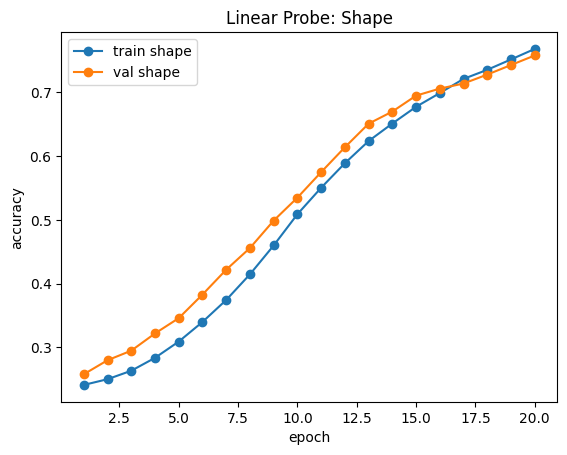

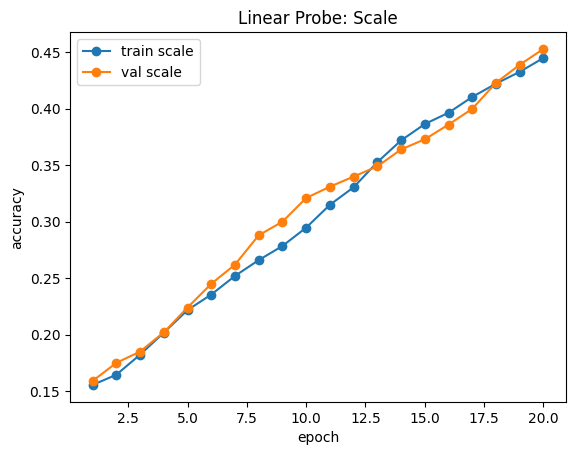

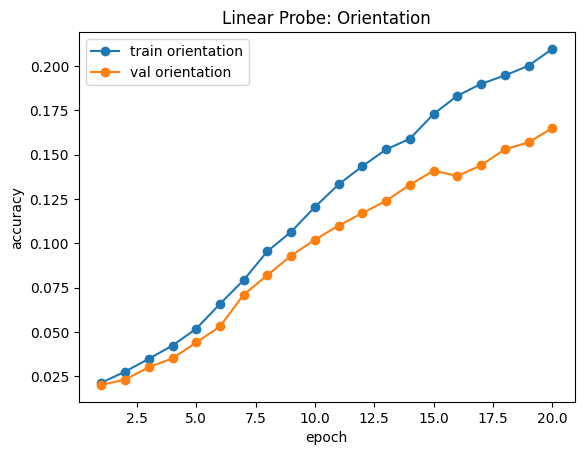


=== LORA SUPERPOSITION ANALYSIS ===


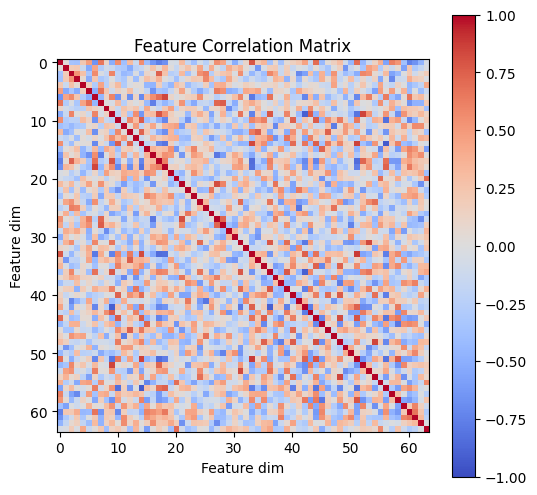

Mean |off-diagonal correlation|: 0.2824


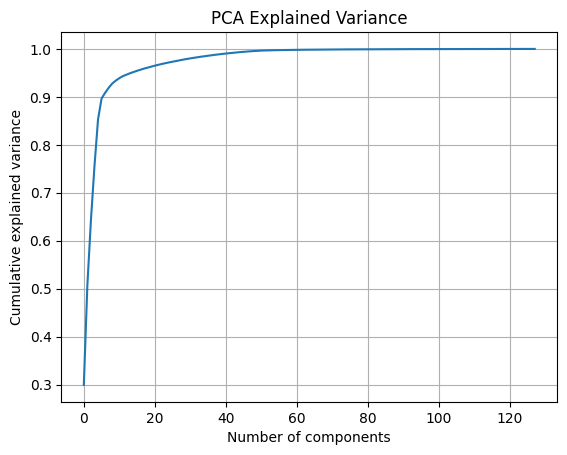

Top 10 components explain: 0.9339
Top 20 components explain: 0.9631


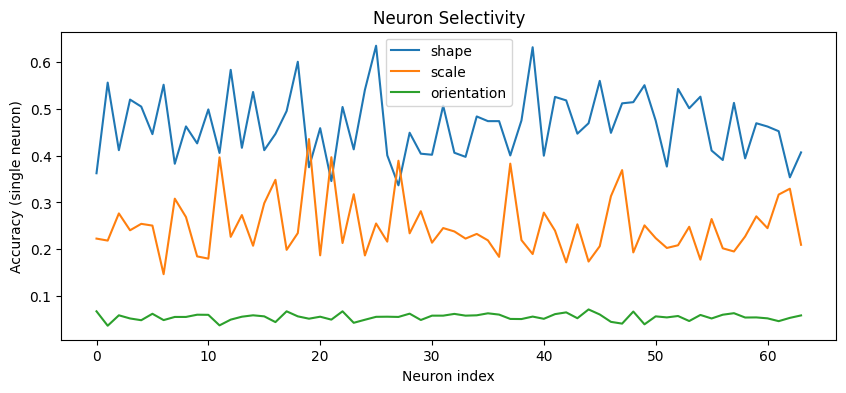


Top neurons per factor:
shape: max=0.634
scale: max=0.435
orientation: max=0.071
LoRA superposition score: 0.2824

========== LORA FINAL RESULTS ==========
Probe Shape       train=0.7682 val=0.7580
Probe Scale       train=0.4450 val=0.4530
Probe Orientation train=0.2097 val=0.1650


In [ ]:
# -----------------------------
# 6) Run LoRA
# -----------------------------
cfg = Config()

model_lora = SupervisedAutoencoderLoRA(
    rep_dim=cfg.rep_dim,
    lora_r=16,
    lora_alpha=32,   # alpha = 2r
)

model_lora = load_baseline_into_lora(
    lora_model=model_lora,
    baseline_model=model_fixed,
)

logs_lora = train_lora_from_baseline(
    model=model_lora,
    train_loader=train_loader_fixed,
    val_loader=val_loader_fixed,
    device=cfg.device,
    steps=2000,
    lr=1e-3,
    cls_weight=cfg.cls_weight,
    print_every=200,
)

plot_training_curves(logs_lora)
show_reconstructions(model_lora, val_loader_fixed, cfg.device, n_show=10)

train_feats_lora, train_targets_lora = extract_features(
    model_lora.encoder,
    train_loader_fixed,
    cfg.device,
    max_samples=4000,
)

val_feats_lora, val_targets_lora = extract_features(
    model_lora.encoder,
    val_loader_fixed,
    cfg.device,
    max_samples=1000,
)

print("LoRA feature shapes:")
print("train_feats_lora:", train_feats_lora.shape)
print("val_feats_lora:", val_feats_lora.shape)

probe_lora, probe_logs_lora = train_linear_probe(
    train_feats=train_feats_lora,
    train_targets=train_targets_lora,
    val_feats=val_feats_lora,
    val_targets=val_targets_lora,
    device=cfg.device,
    epochs=cfg.probe_epochs,
    lr=cfg.probe_lr,
)

plot_probe_curves(probe_logs_lora)

print("\n=== LORA SUPERPOSITION ANALYSIS ===")
corr_lora = plot_feature_correlation(train_feats_lora)
plot_pca_variance(train_feats_lora)
neuron_selectivity(train_feats_lora, train_targets_lora)

print(f"LoRA superposition score: {superposition_score(corr_lora):.4f}")

print("\n========== LORA FINAL RESULTS ==========")
print(f"Probe Shape       train={probe_logs_lora['train_acc_shape'][-1]:.4f} val={probe_logs_lora['val_acc_shape'][-1]:.4f}")
print(f"Probe Scale       train={probe_logs_lora['train_acc_scale'][-1]:.4f} val={probe_logs_lora['val_acc_scale'][-1]:.4f}")
print(f"Probe Orientation train={probe_logs_lora['train_acc_orientation'][-1]:.4f} val={probe_logs_lora['val_acc_orientation'][-1]:.4f}")

Trainable params: 75,953 / 947,346 (8.02%)
[LoRA] step 200/2000 train_total=0.4506 (recon=0.0117, cls=0.4389) | val_acc(shape/scale/orient)=0.999/0.940/0.400
[LoRA] step 400/2000 train_total=0.3992 (recon=0.0119, cls=0.3873) | val_acc(shape/scale/orient)=0.998/0.947/0.404
[LoRA] step 600/2000 train_total=0.3512 (recon=0.0114, cls=0.3398) | val_acc(shape/scale/orient)=0.997/0.947/0.406
[LoRA] step 800/2000 train_total=0.3586 (recon=0.0109, cls=0.3477) | val_acc(shape/scale/orient)=0.999/0.945/0.403
[LoRA] step 1000/2000 train_total=0.4499 (recon=0.0112, cls=0.4387) | val_acc(shape/scale/orient)=0.998/0.942/0.401
[LoRA] step 1200/2000 train_total=0.3305 (recon=0.0112, cls=0.3193) | val_acc(shape/scale/orient)=0.997/0.947/0.413
[LoRA] step 1400/2000 train_total=0.3445 (recon=0.0112, cls=0.3333) | val_acc(shape/scale/orient)=0.999/0.948/0.409
[LoRA] step 1600/2000 train_total=0.2361 (recon=0.0118, cls=0.2243) | val_acc(shape/scale/orient)=0.999/0.949/0.404
[LoRA] step 1800/2000 train_total

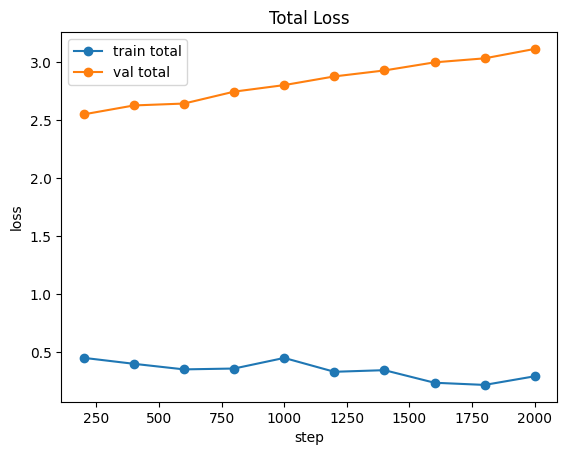

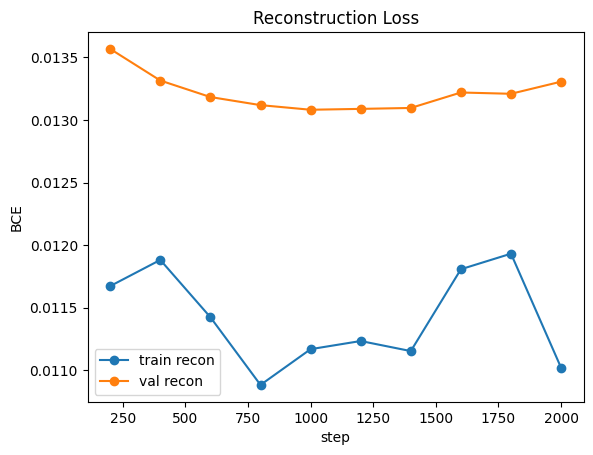

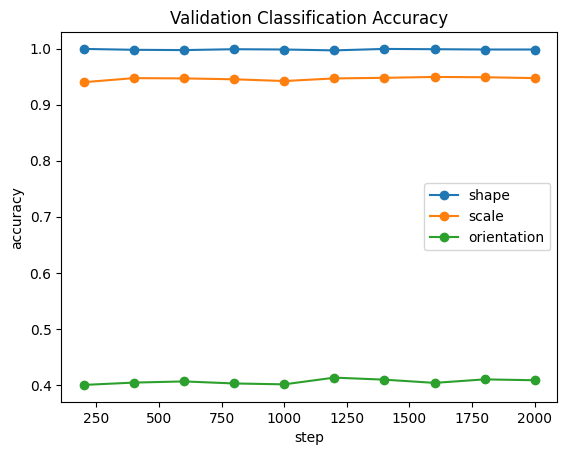

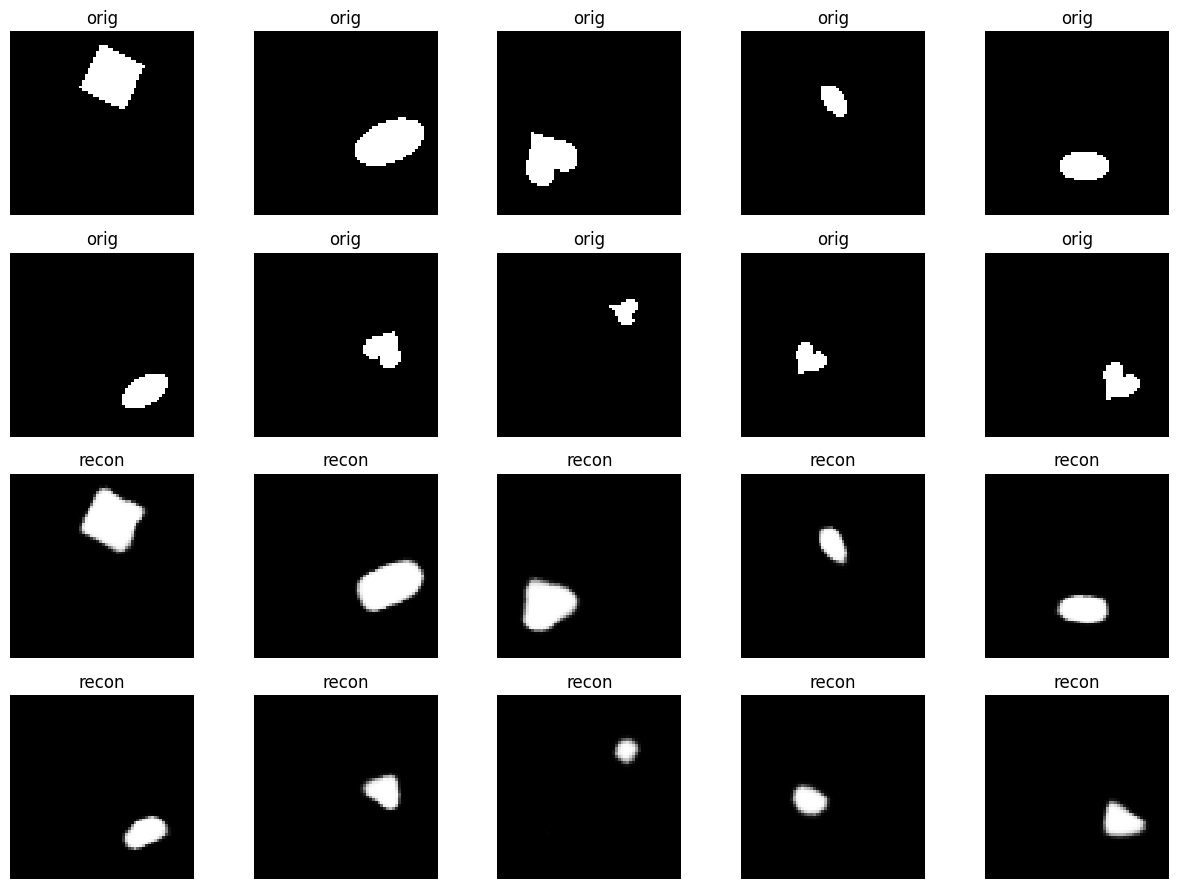

LoRA feature shapes:
train_feats_lora: torch.Size([4000, 128])
val_feats_lora: torch.Size([1000, 128])
[Probe 1/20] train(shape/scale/orient)=0.479/0.142/0.029 | val(shape/scale/orient)=0.454/0.145/0.023
[Probe 2/20] train(shape/scale/orient)=0.496/0.164/0.038 | val(shape/scale/orient)=0.468/0.158/0.036
[Probe 3/20] train(shape/scale/orient)=0.521/0.189/0.045 | val(shape/scale/orient)=0.494/0.173/0.036
[Probe 4/20] train(shape/scale/orient)=0.541/0.221/0.054 | val(shape/scale/orient)=0.513/0.212/0.043
[Probe 5/20] train(shape/scale/orient)=0.569/0.261/0.062 | val(shape/scale/orient)=0.531/0.252/0.053
[Probe 6/20] train(shape/scale/orient)=0.594/0.306/0.073 | val(shape/scale/orient)=0.565/0.298/0.060
[Probe 7/20] train(shape/scale/orient)=0.622/0.345/0.088 | val(shape/scale/orient)=0.601/0.337/0.076
[Probe 8/20] train(shape/scale/orient)=0.639/0.375/0.097 | val(shape/scale/orient)=0.630/0.362/0.084
[Probe 9/20] train(shape/scale/orient)=0.659/0.400/0.104 | val(shape/scale/orient)=0.635/

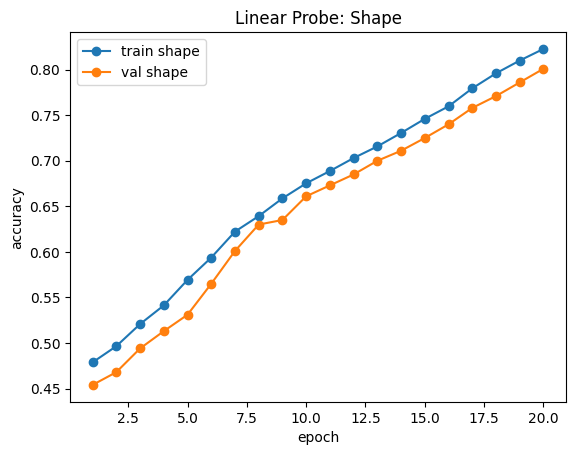

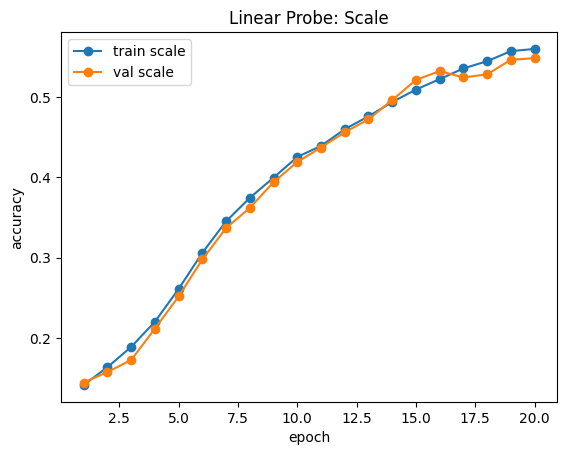

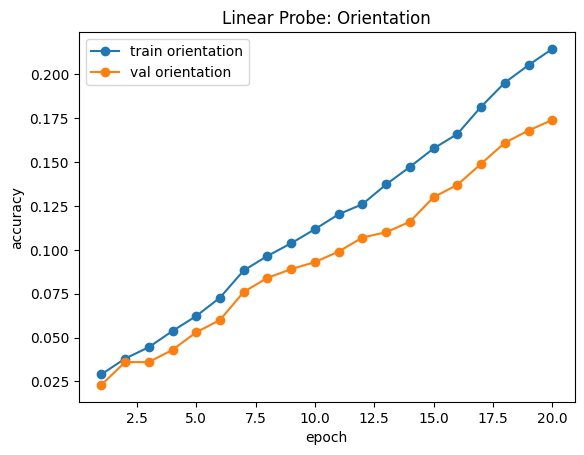


=== LORA SUPERPOSITION ANALYSIS ===


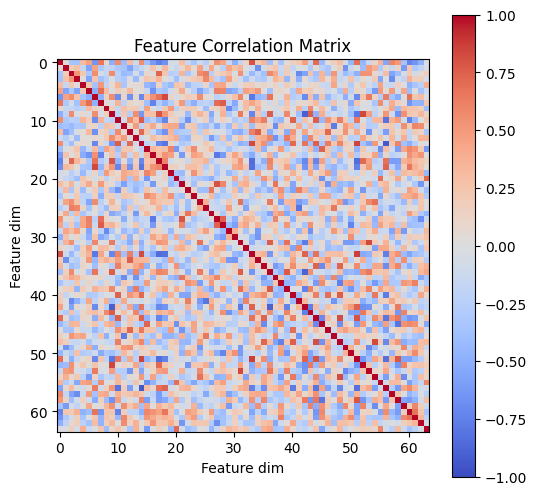

Mean |off-diagonal correlation|: 0.2817


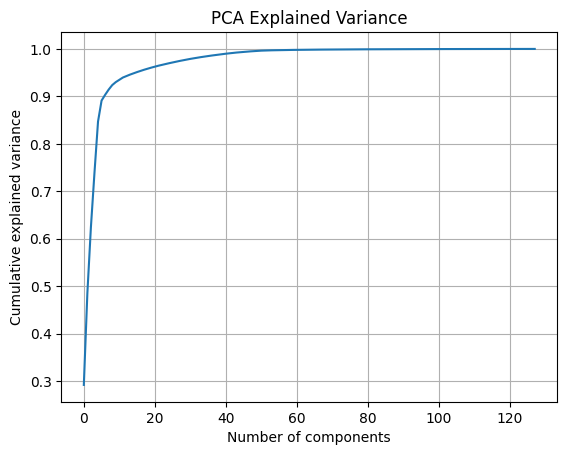

Top 10 components explain: 0.9301
Top 20 components explain: 0.9606


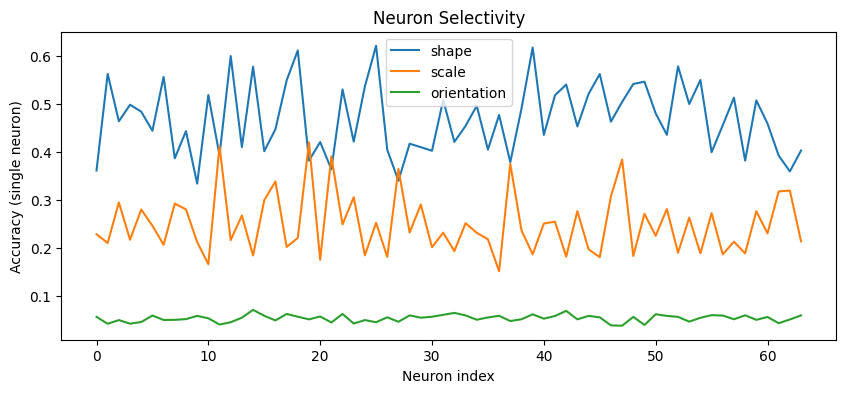


Top neurons per factor:
shape: max=0.622
scale: max=0.420
orientation: max=0.071
LoRA superposition score: 0.2817

========== LORA FINAL RESULTS ==========
Probe Shape       train=0.8227 val=0.8010
Probe Scale       train=0.5595 val=0.5480
Probe Orientation train=0.2145 val=0.1740


In [ ]:
# -----------------------------
# 6) Run LoRA
# -----------------------------
cfg = Config()

model_lora = SupervisedAutoencoderLoRA(
    rep_dim=cfg.rep_dim,
    lora_r=32,
    lora_alpha=64,   # alpha = 2r
)

model_lora = load_baseline_into_lora(
    lora_model=model_lora,
    baseline_model=model_fixed,
)

logs_lora = train_lora_from_baseline(
    model=model_lora,
    train_loader=train_loader_fixed,
    val_loader=val_loader_fixed,
    device=cfg.device,
    steps=2000,
    lr=1e-3,
    cls_weight=cfg.cls_weight,
    print_every=200,
)

plot_training_curves(logs_lora)
show_reconstructions(model_lora, val_loader_fixed, cfg.device, n_show=10)

train_feats_lora, train_targets_lora = extract_features(
    model_lora.encoder,
    train_loader_fixed,
    cfg.device,
    max_samples=4000,
)

val_feats_lora, val_targets_lora = extract_features(
    model_lora.encoder,
    val_loader_fixed,
    cfg.device,
    max_samples=1000,
)

print("LoRA feature shapes:")
print("train_feats_lora:", train_feats_lora.shape)
print("val_feats_lora:", val_feats_lora.shape)

probe_lora, probe_logs_lora = train_linear_probe(
    train_feats=train_feats_lora,
    train_targets=train_targets_lora,
    val_feats=val_feats_lora,
    val_targets=val_targets_lora,
    device=cfg.device,
    epochs=cfg.probe_epochs,
    lr=cfg.probe_lr,
)

plot_probe_curves(probe_logs_lora)

print("\n=== LORA SUPERPOSITION ANALYSIS ===")
corr_lora = plot_feature_correlation(train_feats_lora)
plot_pca_variance(train_feats_lora)
neuron_selectivity(train_feats_lora, train_targets_lora)

print(f"LoRA superposition score: {superposition_score(corr_lora):.4f}")

print("\n========== LORA FINAL RESULTS ==========")
print(f"Probe Shape       train={probe_logs_lora['train_acc_shape'][-1]:.4f} val={probe_logs_lora['val_acc_shape'][-1]:.4f}")
print(f"Probe Scale       train={probe_logs_lora['train_acc_scale'][-1]:.4f} val={probe_logs_lora['val_acc_scale'][-1]:.4f}")
print(f"Probe Orientation train={probe_logs_lora['train_acc_orientation'][-1]:.4f} val={probe_logs_lora['val_acc_orientation'][-1]:.4f}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1) Results table
# -----------------------------
results = pd.DataFrame({
    "model": ["Full FT", "LoRA r=1", "LoRA r=2", "LoRA r=4", "LoRA r=8", "LoRA r=16", "LoRA r=32"],
    "rank": [0, 1, 2, 4, 8, 16, 32],
    "trainable_percent": [100.00, 0.97, 1.21, 1.70, 2.65, 4.51, 8.02],
    "shape_probe": [0.763, 0.778, 0.743, 0.704, 0.698, 0.758, 0.801],
    "scale_probe": [0.488, 0.441, 0.459, 0.462, 0.458, 0.453, 0.548],
    "orientation_probe": [0.142, 0.166, 0.163, 0.153, 0.162, 0.165, 0.174],
    "superposition": [0.2807, 0.2820, 0.2853, 0.2832, 0.2832, 0.2824, 0.2817],
    "top10_pca": [0.9264, 0.9277, 0.9295, 0.9291, 0.9321, 0.9339, 0.9301],
    "top20_pca": [0.9582, 0.9591, 0.9602, 0.9602, 0.9616, 0.9631, 0.9606],
})

display(results)

results.to_csv("results_table.csv", index=False)
print("Saved results_table.csv")

,model,rank,trainable_percent,shape_probe,scale_probe,orientation_probe,superposition,top10_pca,top20_pca
0,Full FT,0,100.00,0.763,0.488,0.142,0.2807,0.9264,0.9582
1,LoRA r=1,1,0.97,0.778,0.441,0.166,0.2820,0.9277,0.9591
2,LoRA r=2,2,1.21,0.743,0.459,0.163,0.2853,0.9295,0.9602
3,LoRA r=4,4,1.70,0.704,0.462,0.153,0.2832,0.9291,0.9602
4,LoRA r=8,8,2.65,0.698,0.458,0.162,0.2832,0.9321,0.9616
5,LoRA r=16,16,4.51,0.758,0.453,0.165,0.2824,0.9339,0.9631
6,LoRA r=32,32,8.02,0.801,0.548,0.174,0.2817,0.9301,0.9606


Saved results_table.csv


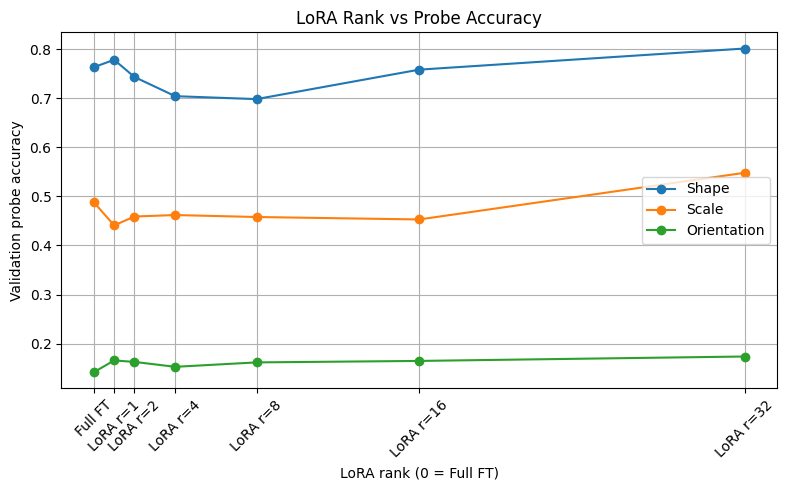

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(results["rank"], results["shape_probe"], marker="o", label="Shape")
plt.plot(results["rank"], results["scale_probe"], marker="o", label="Scale")
plt.plot(results["rank"], results["orientation_probe"], marker="o", label="Orientation")

plt.xlabel("LoRA rank (0 = Full FT)")
plt.ylabel("Validation probe accuracy")
plt.title("LoRA Rank vs Probe Accuracy")
plt.xticks(results["rank"], results["model"], rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("plot_rank_vs_probe_accuracy.png", dpi=300)
plt.show()

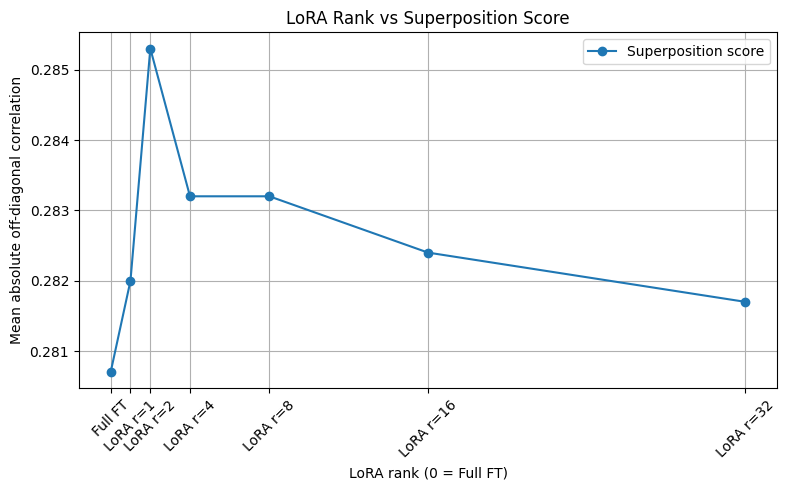

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(results["rank"], results["superposition"], marker="o", label="Superposition score")

plt.xlabel("LoRA rank (0 = Full FT)")
plt.ylabel("Mean absolute off-diagonal correlation")
plt.title("LoRA Rank vs Superposition Score")
plt.xticks(results["rank"], results["model"], rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("plot_rank_vs_superposition.png", dpi=300)
plt.show()

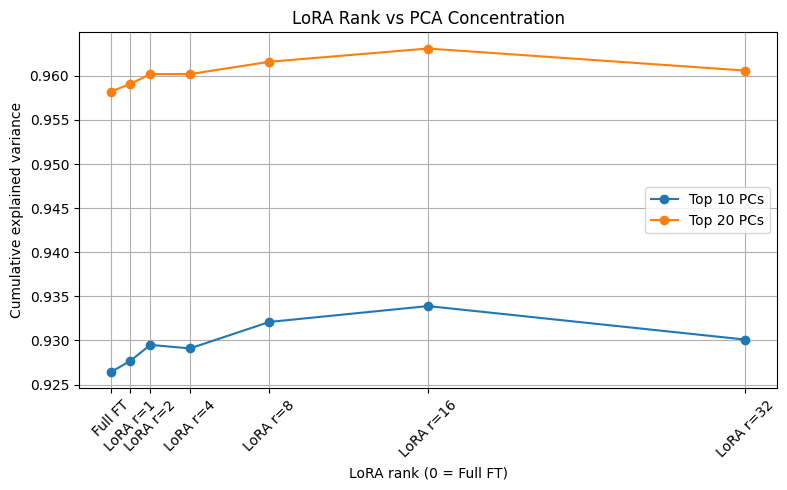

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(results["rank"], results["top10_pca"], marker="o", label="Top 10 PCs")
plt.plot(results["rank"], results["top20_pca"], marker="o", label="Top 20 PCs")

plt.xlabel("LoRA rank (0 = Full FT)")
plt.ylabel("Cumulative explained variance")
plt.title("LoRA Rank vs PCA Concentration")
plt.xticks(results["rank"], results["model"], rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("plot_rank_vs_pca_concentration.png", dpi=300)
plt.show()